In [1]:
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data

aso_df = load_all_features(version='v2')

In [2]:
aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)

Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153


In [3]:
import pandas as pd

merged_df = pd.merge(aso_df, aso_data, on='index_v2')

In [4]:
from tauso.data.consts import INHIBITION

features_to_ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count', 'total_replicate_count', 'Unnamed: 0', 'probe_count']

In [5]:
from tauso.data.consts import MODIFICATION


def add_chemistry_features(df, mod_col_name):
    """
    Adds binary flags (0/1) for 'cet', 'moe', and 'lna' based on the modification string.
    """
    df = df.copy()

    # 1. Initialize columns to 0
    df['cet'] = 0
    df['moe'] = 0
    df['lna'] = 0

    # 2. Set to 1 where the substring exists
    # We use case=False just to be safe, though your data seems consistent.

    # Matches 'cEt/...' and '(S)-cEt/...'
    df.loc[df[mod_col_name].str.contains('cEt', case=False, na=False), 'cet'] = 1

    # Matches 'MOE/...'
    df.loc[df[mod_col_name].str.contains('MOE', case=False, na=False), 'moe'] = 1

    # Matches 'LNA/...'
    df.loc[df[mod_col_name].str.contains('LNA', case=False, na=False), 'lna'] = 1

    return df

# --- Usage Example ---
# Assuming 'filtered_data' is the dataframe from your snippet
# and MODIFICATION is the variable holding the column name string (e.g. 'Modification')

merged_df = add_chemistry_features(merged_df, MODIFICATION)

# Quick check
print(merged_df[[MODIFICATION, 'cet', 'moe', 'lna']].head())

                  Modification  cet  moe  lna
0  cEt/5-methylcytosines/deoxy    1    0    0
1  MOE/5-methylcytosines/deoxy    0    1    0
2  MOE/5-methylcytosines/deoxy    0    1    0
3  MOE/5-methylcytosines/deoxy    0    1    0
4  MOE/5-methylcytosines/deoxy    0    1    0


In [9]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'merged_df' is your loaded DataFrame
df = merged_df.copy()

# ---------------------------------------------------------
# 1. SETUP & COHORT CREATION
# ---------------------------------------------------------
target_col = INHIBITION

features_to_ignore = [
    'log_inhibition',
    INHIBITION,
    'ISIS',
    'index_v2',
    'replicate_count',
    'total_replicate_count',
    'Unnamed: 0'
]

metadata_cols = [CELL_LINE, CANONICAL_GENE]

# Create the specific "Cohort" ID (Cell Line + Gene)
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# Select Features
feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore
    and c not in metadata_cols
]

X = df[feature_cols]
y = df[target_col]
groups = df['cohort']

print(f"Total Cohorts: {df['cohort'].nunique()}")
print(f"Total Features: {len(feature_cols)}")

# ---------------------------------------------------------
# 2. DEFINE THE GPU MODEL
# ---------------------------------------------------------
# We define the model parameters for GPU acceleration.
# 'device': 'cuda' enables the GPU.
# 'tree_method': 'hist' is the fastest algorithm for large data.
model_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'device': 'cuda',          # <--- ENABLES GPU
    'tree_method': 'hist',     # <--- Required for efficient GPU training
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse'
}

# ---------------------------------------------------------
# 3. VALIDATION LOOP (Leave-Groups-Out)
# ---------------------------------------------------------
# Strict validation: We split by GROUPS, not rows.
# Option A: GroupKFold (e.g., 5 folds).
#           Hides 20% of cohorts at a time, trains on 80%, rotates.
# Option B: LeaveOneGroupOut().
#           Hides exactly 1 cohort, trains on N-1. (Very slow if you have many cohorts).

# Using GroupKFold (5 splits) as it is computationally efficient and rigorous.
gkf = GroupKFold(n_splits=5)

fold_metrics = []

print("\nStarting GPU Training with Cohort Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):

    # Slice data using the indices provided by GroupKFold
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Double check that we aren't leaking cohorts
    train_cohorts = set(groups.iloc[train_idx])
    val_cohorts = set(groups.iloc[val_idx])
    assert len(train_cohorts.intersection(val_cohorts)) == 0, "CRITICAL: Data Leakage Detected!"

    # Initialize and Train XGBoost
    model = xgb.XGBRegressor(**model_params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Predict
    preds = model.predict(X_val)

    # Score
    mse = mean_squared_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    fold_metrics.append(r2)

    print(f"Fold {fold+1}: Validation R^2 = {r2:.4f} (Hidden Cohorts: {len(val_cohorts)})")

print("-" * 30)
print(f"Average Cross-Validation R^2: {np.mean(fold_metrics):.4f}")

Total Cohorts: 19
Total Features: 311

Starting GPU Training with Cohort Cross-Validation...


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/core.py:750: UserWarning: [19:36:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1765326939271/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1: Validation R^2 = -0.0167 (Hidden Cohorts: 1)
Fold 2: Validation R^2 = -0.0096 (Hidden Cohorts: 7)
Fold 3: Validation R^2 = 0.1644 (Hidden Cohorts: 3)
Fold 4: Validation R^2 = -0.0903 (Hidden Cohorts: 5)
Fold 5: Validation R^2 = 0.1063 (Hidden Cohorts: 3)
------------------------------
Average Cross-Validation R^2: 0.0308


In [13]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
df = merged_df.copy()
target_col = INHIBITION

features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0'
]
metadata_cols = [CELL_LINE, CANONICAL_GENE]

df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

candidate_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore and c not in metadata_cols
]

# ---------------------------------------------------------
# 2. HIDE TEST COHORT
# ---------------------------------------------------------
# Pick the largest cohort to hide
test_cohort_id = df['cohort'].value_counts().index[0]
print(f"Hidden Test Cohort: {test_cohort_id}")

df_test = df[df['cohort'] == test_cohort_id].copy()
df_dev  = df[df['cohort'] != test_cohort_id].copy()

X_dev = df_dev[candidate_features]
y_dev = df_dev[target_col]
groups_dev = df_dev['cohort']

X_test = df_test[candidate_features]
y_test = df_test[target_col]

# ---------------------------------------------------------
# 3. FAST SELECTION: CV FEATURE IMPORTANCE
# ---------------------------------------------------------
print("\nStarting Cross-Validated Feature Importance...")

# We use a dataframe to accumulate importance scores across folds
importances = pd.DataFrame(index=candidate_features)
importances['total_gain'] = 0.0

gkf = GroupKFold(n_splits=4)

# Params: Slightly deeper trees here to allow model to find interactions among ALL features
model_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'device': 'cuda',
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'n_jobs': -1
}

fold = 1
for train_idx, val_idx in gkf.split(X_dev, y_dev, groups=groups_dev):
    X_tr = X_dev.iloc[train_idx]
    y_tr = y_dev.iloc[train_idx]

    # Train on this fold
    model = xgb.XGBRegressor(**model_params)
    model.fit(X_tr, y_tr)

    # Get Feature Importance (Gain)
    # This tells us how much each feature contributed to reducing error
    fold_importance = pd.Series(model.get_booster().get_score(importance_type='gain'))

    # Map back to our index (fill missing with 0 if a feature wasn't used)
    fold_importance = fold_importance.reindex(candidate_features).fillna(0)

    importances['total_gain'] += fold_importance
    print(f"Fold {fold} complete.")
    fold += 1

# Average the gain
importances['total_gain'] /= 4

# Select Top 40
top_40_features = importances.sort_values(by='total_gain', ascending=False).head(40).index.tolist()

print(f"\nTop 10 Selected Features:\n{top_40_features[:10]}")

# ---------------------------------------------------------
# 4. FINAL VALIDATION
# ---------------------------------------------------------
print("\nRetraining final model on Top 40 features...")

final_model = xgb.XGBRegressor(**model_params)
final_model.fit(X_dev[top_40_features], y_dev)

preds = final_model.predict(X_test[top_40_features])
final_score, _ = spearmanr(y_test, preds)

print(f"FINAL TEST SPEARMAN (Hidden Cohort): {final_score:.4f}")

Hidden Test Cohort: HepaRG_HSD17B13

Starting Cross-Validated Feature Importance...
Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.

Top 10 Selected Features:
['mRNA_HalfLife', 'tAI_score_global_CDS', 'sense_start_x', 'Modification_fraction', 'probe_count', 'PSDNA_RNA_MD_37_GB_TOTAL_HYBR', 'Sequence_gc_content', 'OT_Spec_Rank10_c1000_Exp', 'Treatment_Period(hours)', 'OT_Spec_Rank1_c1000_Exp']

Retraining final model on Top 40 features...
FINAL TEST SPEARMAN (Hidden Cohort): 0.3215


In [12]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
df = merged_df.copy()
target_col = INHIBITION

features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0'
]
metadata_cols = [CELL_LINE, CANONICAL_GENE]

df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

candidate_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore and c not in metadata_cols
]

# ---------------------------------------------------------
# 2. HIDE TEST COHORT
# ---------------------------------------------------------
# Pick the largest cohort to hide
test_cohort_id = df['cohort'].value_counts().index[0]
print(f"Hidden Test Cohort: {test_cohort_id}")

df_test = df[df['cohort'] == test_cohort_id].copy()
df_dev  = df[df['cohort'] != test_cohort_id].copy()

X_dev = df_dev[candidate_features]
y_dev = df_dev[target_col]
groups_dev = df_dev['cohort']

X_test = df_test[candidate_features]
y_test = df_test[target_col]

# ---------------------------------------------------------
# 3. FAST SELECTION: CV FEATURE IMPORTANCE
# ---------------------------------------------------------
print("\nStarting Cross-Validated Feature Importance...")

# We use a dataframe to accumulate importance scores across folds
importances = pd.DataFrame(index=candidate_features)
importances['total_gain'] = 0.0

gkf = GroupKFold(n_splits=4)

# Params: Slightly deeper trees here to allow model to find interactions among ALL features
model_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'device': 'cuda',
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'n_jobs': -1
}

fold = 1
for train_idx, val_idx in gkf.split(X_dev, y_dev, groups=groups_dev):
    X_tr = X_dev.iloc[train_idx]
    y_tr = y_dev.iloc[train_idx]

    # Train on this fold
    model = xgb.XGBRegressor(**model_params)
    model.fit(X_tr, y_tr)

    # Get Feature Importance (Gain)
    # This tells us how much each feature contributed to reducing error
    fold_importance = pd.Series(model.get_booster().get_score(importance_type='gain'))

    # Map back to our index (fill missing with 0 if a feature wasn't used)
    fold_importance = fold_importance.reindex(candidate_features).fillna(0)

    importances['total_gain'] += fold_importance
    print(f"Fold {fold} complete.")
    fold += 1

# Average the gain
importances['total_gain'] /= 4

# Select Top 40
top_40_features = importances.sort_values(by='total_gain', ascending=False).head(40).index.tolist()

print(f"\nTop 10 Selected Features:\n{top_40_features[:10]}")

# ---------------------------------------------------------
# 4. FINAL VALIDATION
# ---------------------------------------------------------
print("\nRetraining final model on Top 40 features...")

final_model = xgb.XGBRegressor(**model_params)
final_model.fit(X_dev[top_40_features], y_dev)

preds = final_model.predict(X_test[top_40_features])
final_score, _ = spearmanr(y_test, preds)

print(f"FINAL TEST SPEARMAN (Hidden Cohort): {final_score:.4f}")

Hidden Test Cohort: HepaRG_HSD17B13

Starting Cross-Validated Feature Importance...
Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.

Top 10 Selected Features:
['mRNA_HalfLife', 'tAI_score_global_CDS', 'sense_start_x', 'Modification_fraction', 'probe_count', 'PSDNA_RNA_MD_37_GB_TOTAL_HYBR', 'Sequence_gc_content', 'OT_Spec_Rank10_c1000_Exp', 'Treatment_Period(hours)', 'OT_Spec_Rank1_c1000_Exp']

Retraining final model on Top 40 features...
FINAL TEST SPEARMAN (Hidden Cohort): 0.3215


In [15]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from scipy.stats import spearmanr
from tqdm import tqdm # Progress bar is helpful here

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
df = merged_df.copy() # Assuming merged_df is your source
target_col = INHIBITION

features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0', 'probe_count'
]
metadata_cols = [CELL_LINE, CANONICAL_GENE]

# Create Cohort ID
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

candidate_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore and c not in metadata_cols
]

# ---------------------------------------------------------
# 2. FEATURE SELECTION (Using 4-Fold on entire dataset)
# ---------------------------------------------------------
print("Running Feature Selection to find Top 10...")

X = df[candidate_features]
y = df[target_col]
groups = df['cohort']

# Accumulate importance
importances = pd.DataFrame(index=candidate_features)
importances['total_gain'] = 0.0

gkf = GroupKFold(n_splits=4)

model_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'device': 'cuda',
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'n_jobs': -1,
    'verbosity': 0
}

for train_idx, val_idx in gkf.split(X, y, groups=groups):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    model = xgb.XGBRegressor(**model_params)
    model.fit(X_tr, y_tr)

    # Get Gain
    fold_imp = pd.Series(model.get_booster().get_score(importance_type='gain'))
    fold_imp = fold_imp.reindex(candidate_features).fillna(0)
    importances['total_gain'] += fold_imp

# Average and Select Top 10
importances['total_gain'] /= 4
top_10_features = importances.sort_values(by='total_gain', ascending=False).head(10).index.tolist()

print(f"\nTop 10 Features Selected: {top_10_features}")

# ---------------------------------------------------------
# 3. LEAVE-ONE-GROUP-OUT VALIDATION (The "Robust" Test)
# ---------------------------------------------------------
print("\n" + "="*50)
print(f"Starting Leave-One-Cohort-Out Validation on {groups.nunique()} cohorts...")
print("Training on N-1 cohorts, Testing on 1 hidden cohort (Repeated for all).")

# Setup for the loop
logo = LeaveOneGroupOut()
logo_scores = []
logo_details = []

X_final = df[top_10_features] # Only use the selected features
y_final = df[target_col]

# Iterate through every single cohort
# We use tqdm to show progress because if you have 100+ cohorts, this takes a moment
for train_idx, val_idx in tqdm(logo.split(X_final, y_final, groups=groups), total=groups.nunique()):

    # Slice data
    X_train, y_train = X_final.iloc[train_idx], y_final.iloc[train_idx]
    X_val, y_val = X_final.iloc[val_idx], y_final.iloc[val_idx]

    # Identify which cohort is hidden (for reporting)
    hidden_cohort_name = groups.iloc[val_idx].iloc[0]

    # Train Model (Fast params for loop)
    # Note: We re-train a fresh model from scratch for every single cohort
    model = xgb.XGBRegressor(**model_params)
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_val)

    # Calculate Metric (Spearman)
    # Handle edge cases (single sample cohorts or constant predictions)
    if len(preds) < 2:
        continue # Can't calculate correlation on 1 sample

    try:
        score, _ = spearmanr(y_val, preds)
        if np.isnan(score): score = 0.0
    except:
        score = 0.0

    logo_scores.append(score)
    logo_details.append({'cohort': hidden_cohort_name, 'spearman': score, 'n_samples': len(y_val)})

# ---------------------------------------------------------
# 4. REPORTING
# ---------------------------------------------------------
results_df = pd.DataFrame(logo_details)

print("\n" + "="*50)
print(f"Global Average Spearman (Across {len(results_df)} cohorts): {np.mean(logo_scores):.4f}")
print(f"Median Spearman: {np.median(logo_scores):.4f}")
print("="*50)

print("\nBest Performing Cohorts:")
print(results_df.sort_values(by='spearman', ascending=False).head(5))

print("\nWorst Performing Cohorts (Hardest to Predict):")
print(results_df.sort_values(by='spearman', ascending=True).head(5))

Running Feature Selection to find Top 10...

Top 10 Features Selected: ['mRNA_HalfLife', 'OT_Spec_Rank1_c1000_Exp', 'tAI_score_global_CDS', 'ENC_score_global_CDS', 'sense_start_x', 'OT_Spec_Rank10_c1000_Exp', 'mfe_win45_flank120_step4', 'ASO_volume(nM)', 'PSDNA_RNA_MD_37_GB_TOTAL_HYBR', 'OT_Spec_Rank5_c1000_Exp']

Starting Leave-One-Cohort-Out Validation on 19 cohorts...
Training on N-1 cohorts, Testing on 1 hidden cohort (Repeated for all).


100%|██████████| 19/19 [00:29<00:00,  1.58s/it]


Global Average Spearman (Across 19 cohorts): 0.2666
Median Spearman: 0.2331

Best Performing Cohorts:
            cohort  spearman  n_samples
4        A431_SOD1  1.000000          4
15   NCI-H460_KRAS  0.769231         12
0       A-431_IRF5  0.472748         36
14      MM.1R_IRF4  0.394969       1738
16  SK-MEL-28_IRF4  0.364315       2671

Worst Performing Cohorts (Hardest to Predict):
          cohort  spearman  n_samples
8     HepG2_SOD1 -0.061106        273
17  SNU-449_YAP1 -0.039454        181
2      A431_KRAS -0.018343        489
13    KMS11_IRF4 -0.013755         13
18    U251_HTRA1  0.064952        126


In [20]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. CONFIGURATION & SETUP
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()
target_col = INHIBITION

# Update with your actual column name for volume
VOLUME_COL = 'ASO_volume(nM)'

PARALLEL_JOBS = 100
MAX_FEATURES_TO_SELECT = 20

features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0'
]
metadata_cols = [CELL_LINE, CANONICAL_GENE]

# Cohort Creation
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# --- FILTERING STEP ---
cohort_counts = df['cohort'].value_counts()
large_cohorts = cohort_counts[cohort_counts >= 40].index
df_robust = df[df['cohort'].isin(large_cohorts)].copy()

print(f"Filtering: {len(large_cohorts)} robust cohorts kept out of {len(cohort_counts)}")

candidate_features = [
    c for c in df_robust.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore and c not in metadata_cols
]

# ---------------------------------------------------------
# 2. DATA SPLIT (Hide Test Set)
# ---------------------------------------------------------
# Selecting the largest cohort from the ROBUST set to hide
test_cohort_id = df_robust['cohort'].value_counts().index[0]
print(f"Hidden Test Cohort: {test_cohort_id}")

df_test = df_robust[df_robust['cohort'] == test_cohort_id].copy()
df_dev  = df_robust[df_robust['cohort'] != test_cohort_id].copy()

X_dev = df_dev[candidate_features]
y_dev = df_dev[target_col]
groups_dev = df_dev['cohort']

X_test = df_test[candidate_features]
y_test = df_test[target_col]

# ---------------------------------------------------------
# 3. PRE-CALCULATE CV SPLITS
# ---------------------------------------------------------
gkf = GroupKFold(n_splits=4)
cv_indices = list(gkf.split(X_dev, y_dev, groups=groups_dev))

# ---------------------------------------------------------
# 4. WORKER FUNCTION
# ---------------------------------------------------------
def evaluate_candidate_feature(candidate, current_selected, X, y, indices):
    features_to_use = current_selected + [candidate]
    scores = []
    params = {
        'n_estimators': 100,
        'max_depth': 4,
        'learning_rate': 0.1,
        'device': 'cuda',
        'tree_method': 'hist',
        'eval_metric': 'rmse',
        'n_jobs': 1,
        'verbosity': 0
    }
    for train_idx, val_idx in indices:
        X_tr, y_tr = X.iloc[train_idx][features_to_use], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx][features_to_use], y.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        try:
            s, _ = spearmanr(y_val, preds)
            if np.isnan(s): s = 0
        except:
            s = 0
        scores.append(s)
    return candidate, np.mean(scores)

# ---------------------------------------------------------
# 5. PARALLEL SELECTION LOOP
# ---------------------------------------------------------
# Pre-seeding with Volume
selected_features = [VOLUME_COL]

# Calculate initial score with just Volume
_, initial_score = evaluate_candidate_feature(VOLUME_COL, [], X_dev, y_dev, cv_indices)
best_global_score = initial_score

print(f"\nSeeding model with: {VOLUME_COL}")
print(f"Initial CV Spearman (Volume only): {initial_score:.4f}")

print(f"\nStarting Parallel Forward Selection...")

# Adjust range because we already have 1 feature
for i in range(len(selected_features), MAX_FEATURES_TO_SELECT):
    remaining_features = [f for f in candidate_features if f not in selected_features]

    results = Parallel(n_jobs=PARALLEL_JOBS, backend='threading')(
        delayed(evaluate_candidate_feature)(
            feat,
            selected_features,
            X_dev,
            y_dev,
            cv_indices
        )
        for feat in tqdm(remaining_features, desc=f"Round {i+1}", leave=False)
    )

    best_feature_this_round = None
    best_score_this_round = -1.0

    for feat, score in results:
        if score > best_score_this_round:
            best_score_this_round = score
            best_feature_this_round = feat

    if best_feature_this_round:
        improvement = best_score_this_round - best_global_score
        selected_features.append(best_feature_this_round)

        print(f"Round {i+1} | Selected: {best_feature_this_round} | CV Spearman: {best_score_this_round:.4f} | Gain: {improvement:.4f}")

        # Stopping early if gain is negligible
        if improvement < 0.001:
             print("Performance plateaued. Stopping early.")
             break
        best_global_score = best_score_this_round
    else:
        break

# ---------------------------------------------------------
# 6. FINAL VALIDATION
# ---------------------------------------------------------
print(f"\nFinal Selected Features: {selected_features}")

final_model = xgb.XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, device='cuda', tree_method='hist')
final_model.fit(X_dev[selected_features], y_dev)

test_preds = final_model.predict(X_test[selected_features])
test_spearman, _ = spearmanr(y_test, test_preds)

print(f"FINAL TEST SPEARMAN (Hidden Cohort {test_cohort_id}): {test_spearman:.4f}")

Filtering: 14 robust cohorts kept out of 19
Hidden Test Cohort: HepaRG_HSD17B13

Seeding model with: ASO_volume(nM)
Initial CV Spearman (Volume only): -0.1034

Starting Parallel Forward Selection...


Round 2:   0%|          | 0/310 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [19]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneGroupOut
from scipy.stats import spearmanr
from tqdm import tqdm

# 1. SETUP & FILTERING
# ---------------------------------------------------------
final_features = [
    'sense_start_x',
    'Treatment_Period(hours)',
    'off_target_score_general_ARTM_n50_c800',
    'Sequence_at_skew',
    'CAI_score_70_CDS',
    'RNaseH1_Krel_score_R4a_krel_dynamic',
    'Sequence_tandem_repeats_score',
    'mfe_win35_flank120_step10',
    'OT_Spec_Rank3_c400_Score',
    'PSDNA_RNA_MD_37_PB_TOTAL_HYBR'
]

df = merged_df.copy()
target_col = INHIBITION
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# --- FILTERING STEP ---
cohort_counts = df['cohort'].value_counts()
large_cohorts = cohort_counts[cohort_counts >= 40].index
df_filtered = df[df['cohort'].isin(large_cohorts)].copy()

print(f"Original Cohorts: {len(cohort_counts)}")
print(f"Filtered Cohorts (N >= 40): {len(large_cohorts)}")
print(f"Total Rows Remaining: {len(df_filtered)}")

# 2. SEPARATE SETS
# ---------------------------------------------------------
test_cohort_id = 'HepaRG_HSD17B13'

# Ensure the test cohort itself isn't filtered out by the N=40 rule!
if test_cohort_id not in df_filtered['cohort'].unique():
    print(f"WARNING: {test_cohort_id} has < 40 rows and was filtered. Including it back for testing.")
    df_test = df[df['cohort'] == test_cohort_id].copy()
else:
    df_test = df_filtered[df_filtered['cohort'] == test_cohort_id].copy()

df_dev = df_filtered[df_filtered['cohort'] != test_cohort_id].copy()

X_dev = df_dev[final_features]
y_dev = df_dev[target_col]
groups_dev = df_dev['cohort']

X_test = df_test[final_features]
y_test = df_test[target_col]

# 3. LEAVE-ONE-COHORT-OUT
# ---------------------------------------------------------
logo = LeaveOneGroupOut()
logo_results = []

model_params = {
    'n_estimators': 500,
    'max_depth': 4,
    'learning_rate': 0.05,
    'device': 'cuda',
    'tree_method': 'hist',
    'verbosity': 0
}

print(f"\nValidating on {groups_dev.nunique()} development cohorts...")

for train_idx, val_idx in tqdm(logo.split(X_dev, y_dev, groups=groups_dev), total=groups_dev.nunique()):
    X_tr, y_tr = X_dev.iloc[train_idx], y_dev.iloc[train_idx]
    X_val, y_val = X_dev.iloc[val_idx], y_dev.iloc[val_idx]

    cohort_name = groups_dev.iloc[val_idx].iloc[0]

    model = xgb.XGBRegressor(**model_params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    corr, _ = spearmanr(y_val, preds)
    logo_results.append({'cohort': cohort_name, 'spearman': corr, 'n': len(y_val)})

results_df = pd.DataFrame(logo_results)

# 4. FINAL TEST
# ---------------------------------------------------------
print("\n" + "="*50)
print(f"CV AVG SPEARMAN (Robust Cohorts): {results_df['spearman'].mean():.4f}")
print(f"CV MEDIAN SPEARMAN: {results_df['spearman'].median():.4f}")
print("="*50)

print(f"\nTraining Final Model and testing on {test_cohort_id}...")
final_model = xgb.XGBRegressor(**model_params)
final_model.fit(X_dev, y_dev)

test_preds = final_model.predict(X_test)
final_test_corr, _ = spearmanr(y_test, test_preds)

print(f"FINAL HIDDEN TEST SPEARMAN: {final_test_corr:.4f}")
print("="*50)

# Identify the "Problem Cohorts" that are still hard to predict despite having enough data
print("\nHardest Robust Cohorts to Predict:")
print(results_df.sort_values('spearman').head(5))

Original Cohorts: 19
Filtered Cohorts (N >= 40): 14
Total Rows Remaining: 18071

Validating on 13 development cohorts...


100%|██████████| 13/13 [00:12<00:00,  1.04it/s]



CV AVG SPEARMAN (Robust Cohorts): 0.2923
CV MEDIAN SPEARMAN: 0.3192

Training Final Model and testing on HepaRG_HSD17B13...
FINAL HIDDEN TEST SPEARMAN: 0.1094

Hardest Robust Cohorts to Predict:
          cohort  spearman     n
0     A431_APOL1  0.079083   805
6   HepaRG_KLKB1  0.101552   951
1      A431_KRAS  0.156905   489
4    HepG2_DGAT2  0.177876  1814
11  SNU-449_YAP1  0.267815   181


In [22]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. PREPARE DATA & SPLITS (STRICT COHORT SEPARATION)
# ---------------------------------------------------------
df = merged_df.copy()
VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Create Cohort ID
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# Filter Small Cohorts
counts = df['cohort'].value_counts()
df = df[df['cohort'].isin(counts[counts >= 40].index)].copy()

# Define Hidden Test Cohort
test_cohort_id = 'HepaRG_HSD17B13'

# Ensure Test Cohort Exists in Filtered Data
if test_cohort_id not in df['cohort'].unique():
    # If filtered out, pull it back from original for testing
    print(f"Test cohort {test_cohort_id} was small/filtered. Pulling from raw.")
    df_test = merged_df[merged_df[CELL_LINE].astype(str) + '_' + merged_df[CANONICAL_GENE].astype(str) == test_cohort_id].copy()
else:
    df_test = df[df['cohort'] == test_cohort_id].copy()

# Dev Set is everything NOT the test cohort
df_train = df[df['cohort'] != test_cohort_id].copy()

# Pick 5 Random Features for the test
features_to_ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count', 'total_replicate_count', 'Unnamed: 0']
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in features_to_ignore and c != VOLUME_COL]
selected_features = list(np.random.choice(numeric_cols, 5, replace=False))

print(f"Training on {df_train['cohort'].nunique()} cohorts. Testing on Hidden: {test_cohort_id}")
print(f"Features: {selected_features}")

# ---------------------------------------------------------
# MODEL A: "BLACK BOX" (Volume is a Feature)
# ---------------------------------------------------------
print("\n--- Model A: Black Box (Volume as Feature) ---")

features_A = selected_features + [VOLUME_COL]
model_a = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, device='cuda', tree_method='hist', verbosity=0)

model_a.fit(df_train[features_A], df_train[TARGET_COL])
preds_a = model_a.predict(df_test[features_A])

score_a, _ = spearmanr(df_test[TARGET_COL], preds_a)
print(f"Model A Spearman (Hidden Cohort): {score_a:.4f}")

# ---------------------------------------------------------
# MODEL B: "PHYSICS INFORMED" (Predicting derived EC50)
# ---------------------------------------------------------
print("\n--- Model B: Physics Informed (Predicting EC50) ---")

# 1. Transform Target: Inhibition -> Log_EC50
# Clip to 1-99 to avoid math errors (singularity at 0 and 100)
train_inh = df_train[TARGET_COL].clip(1, 99) / 100.0

# Inverted Michaelis-Menten: EC50 = Volume * ( (1/Inhibition) - 1 )
train_ec50 = df_train[VOLUME_COL] * ( (1.0 / train_inh) - 1.0 )
y_train_log_ec50 = np.log10(train_ec50)

# 2. Train on Sequence Features ONLY (No Volume)
features_B = selected_features
model_b = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, device='cuda', tree_method='hist', verbosity=0)

model_b.fit(df_train[features_B], y_train_log_ec50)

# 3. Predict Log_EC50 on Hidden Cohort
preds_log_ec50 = model_b.predict(df_test[features_B])

# 4. Reconstruct Inhibition: Volume / (Volume + Pred_EC50)
pred_ec50_val = 10**preds_log_ec50
preds_b_reconstructed = (df_test[VOLUME_COL] / (df_test[VOLUME_COL] + pred_ec50_val)) * 100.0

score_b, _ = spearmanr(df_test[TARGET_COL], preds_b_reconstructed)
print(f"Model B Spearman (Hidden Cohort): {score_b:.4f}")

# ---------------------------------------------------------
# COMPARISON
# ---------------------------------------------------------
print("\n" + "="*30)
diff = score_b - score_a
print(f"Physics Model Advantage: {diff:.4f}")
print("="*30)

Training on 13 cohorts. Testing on Hidden: HepaRG_HSD17B13
Features: [np.str_('RNaseH1_score_R7_dynamic'), np.str_('OT_Spec_Rank9_c400_Exp'), np.str_('OT_Spec_Rank7_c800_Exp'), np.str_('off_target_score_general_ARTM_n50_c1000'), np.str_('Sequence_hairpin_tm')]

--- Model A: Black Box (Volume as Feature) ---
Model A Spearman (Hidden Cohort): 0.2144

--- Model B: Physics Informed (Predicting EC50) ---
Model B Spearman (Hidden Cohort): 0.3882

Physics Model Advantage: 0.1738


In [23]:
preds_a = model_a.predict(df_train[features_A])

score_a, _ = spearmanr(df_train[TARGET_COL], preds_a)
score_a

np.float64(0.6831719664481235)

In [26]:
preds_log_ec50 = model_b.predict(df_train[features_B])

# 4. Reconstruct Inhibition: Volume / (Volume + Pred_EC50)
pred_ec50_val = 10**preds_log_ec50
preds_b_reconstructed = (df_train[VOLUME_COL] / (df_train[VOLUME_COL] + pred_ec50_val)) * 100.0
score_b, _ = spearmanr(df_train[TARGET_COL], preds_b_reconstructed)
score_b

np.float64(0.5678556059214362)

In [27]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()

VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Performance & Strategy
PARALLEL_JOBS = 100        # Adjust based on GPU VRAM
MAX_FEATURES_TO_SELECT = 20
MIN_COHORT_SIZE = 40       # Robustness filter

# ---------------------------------------------------------
# 2. DATA PREP: PHYSICS TARGET CREATION
# ---------------------------------------------------------
# Clip Inhibition (1% to 99%) to prevent math errors (div by zero)
df['inh_clipped'] = df[TARGET_COL].clip(1, 99) / 100.0

# Calculate Log_EC50 (The new Target)
# Formula: EC50 = Volume * ( (1/Inhibition) - 1 )
df['ec50_derived'] = df[VOLUME_COL] * ( (1.0 / df['inh_clipped']) - 1.0 )
df['log_ec50'] = np.log10(df['ec50_derived'])

# ---------------------------------------------------------
# 3. FILTERING & COHORT SPLIT
# ---------------------------------------------------------
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# Filter for robust cohorts
counts = df['cohort'].value_counts()
large_cohorts = counts[counts >= MIN_COHORT_SIZE].index
df_robust = df[df['cohort'].isin(large_cohorts)].copy()

print(f"Cohorts: {len(large_cohorts)} robust (N>={MIN_COHORT_SIZE})")

# Hide Test Cohort
test_cohort_id = 'HepaRG_HSD17B13' # Focusing on your specific target
if test_cohort_id not in df_robust['cohort'].unique():
     print(f"Warning: {test_cohort_id} was filtered out. Pulling from raw.")
     # (Logic to pull back if needed, assuming it's in large_cohorts for now)

df_test = df_robust[df_robust['cohort'] == test_cohort_id].copy()
df_dev  = df_robust[df_robust['cohort'] != test_cohort_id].copy()

# ---------------------------------------------------------
# 4. FEATURE SETUP (NO VOLUME ALLOWED)
# ---------------------------------------------------------
features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0',
    'inh_clipped', 'ec50_derived', 'log_ec50',
    VOLUME_COL # <--- EXCLUDED! Physics handles this.
]
metadata_cols = [CELL_LINE, CANONICAL_GENE, 'cohort']

candidate_features = [
    c for c in df_robust.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore and c not in metadata_cols
]

# Set up Training matrices
# NOTE: We train on sequence features to predict 'log_ec50'
X_dev = df_dev[candidate_features]
y_dev_phys = df_dev['log_ec50']    # Train Target
y_dev_real = df_dev[TARGET_COL]    # Scoring Target (Inhibition)
vol_dev    = df_dev[VOLUME_COL]    # Needed for reconstruction

X_test = df_test[candidate_features]
y_test_phys = df_test['log_ec50']
y_test_real = df_test[TARGET_COL]
vol_test    = df_test[VOLUME_COL]

groups_dev = df_dev['cohort']

# ---------------------------------------------------------
# 5. WORKER FUNCTION (PHYSICS AWARE)
# ---------------------------------------------------------
# Pre-calculate indices
gkf = GroupKFold(n_splits=4)
cv_indices = list(gkf.split(X_dev, y_dev_real, groups=groups_dev))

def evaluate_physics_candidate(candidate, current_selected, X, y_log_ec50, y_real_inh, volumes, indices):
    features_to_use = current_selected + [candidate]
    scores = []

    # Fast Model Params
    params = {
        'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1,
        'device': 'cuda', 'tree_method': 'hist', 'eval_metric': 'rmse',
        'n_jobs': 1, 'verbosity': 0
    }

    for train_idx, val_idx in indices:
        # 1. Train on Log_EC50
        X_tr = X.iloc[train_idx][features_to_use]
        y_tr_ec50 = y_log_ec50.iloc[train_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr_ec50)

        # 2. Predict Log_EC50
        X_val = X.iloc[val_idx][features_to_use]
        pred_log_ec50 = model.predict(X_val)

        # 3. PHYSICS RECONSTRUCTION
        # Pred_Inh = Vol / (Vol + 10^Pred_LogEC50)
        val_vols = volumes.iloc[val_idx]
        pred_ec50 = 10**pred_log_ec50
        pred_inh_reconstructed = (val_vols / (val_vols + pred_ec50)) * 100.0

        # 4. Score against REAL Inhibition
        # We validate on the thing we actually care about (Inhibition %)
        y_val_real = y_real_inh.iloc[val_idx]
        try:
            s, _ = spearmanr(y_val_real, pred_inh_reconstructed)
            if np.isnan(s): s = 0
        except:
            s = 0
        scores.append(s)

    return candidate, np.mean(scores)

# ---------------------------------------------------------
# 6. PARALLEL SELECTION LOOP
# ---------------------------------------------------------
selected_features = []
best_global_score = -1.0

print(f"\nStarting Physics-Informed Greedy Selection...")
print(f"Goal: Find features that predict EC50 (Potency), validated on Inhibition.")

for i in range(MAX_FEATURES_TO_SELECT):
    remaining_features = [f for f in candidate_features if f not in selected_features]

    # Run Parallel Jobs
    results = Parallel(n_jobs=PARALLEL_JOBS, backend='threading')(
        delayed(evaluate_physics_candidate)(
            feat, selected_features,
            X_dev, y_dev_phys, y_dev_real, vol_dev,
            cv_indices
        )
        for feat in tqdm(remaining_features, desc=f"Round {i+1}", leave=False)
    )

    # Find Best
    best_feature_this_round = None
    best_score_this_round = -1.0

    for feat, score in results:
        if score > best_score_this_round:
            best_score_this_round = score
            best_feature_this_round = feat

    # Update
    if best_feature_this_round:
        improvement = best_score_this_round - best_global_score
        selected_features.append(best_feature_this_round)

        print(f"Round {i+1} | Selected: {best_feature_this_round} | CV Spearman: {best_score_this_round:.4f} | Gain: {improvement:.4f}")

        if improvement < 0.002: # Strict stopping
             print("Performance plateaued.")
             break
        best_global_score = best_score_this_round
    else:
        break

# ---------------------------------------------------------
# 7. FINAL TEST ON HEPARG
# ---------------------------------------------------------
print(f"\nFinal Features: {selected_features}")

# Train Final Model (Predicting EC50)
final_model = xgb.XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, device='cuda', tree_method='hist')
final_model.fit(X_dev[selected_features], y_dev_phys) # Train on EC50

# Test
pred_log_ec50_test = final_model.predict(X_test[selected_features])
pred_ec50_test = 10**pred_log_ec50_test
final_preds = (vol_test / (vol_test + pred_ec50_test)) * 100.0

score, _ = spearmanr(y_test_real, final_preds)
print(f"FINAL TEST SPEARMAN (Physics-Informed): {score:.4f}")

Cohorts: 14 robust (N>=40)

Starting Physics-Informed Greedy Selection...
Goal: Find features that predict EC50 (Potency), validated on Inhibition.


Round 1 | Selected: mfe_win65_flank120_step15 | CV Spearman: 0.3953 | Gain: 1.3953


Round 2 | Selected: Sequence_at_skew | CV Spearman: 0.4250 | Gain: 0.0297


Round 3 | Selected: ENC_score_30_CDS | CV Spearman: 0.4442 | Gain: 0.0192


Round 4 | Selected: RNaseH1_score_dinucleotide_R4a_dinuc_dynamic | CV Spearman: 0.4499 | Gain: 0.0057


...

Round 7 | Selected: off_target_single_PPIA_c1200 | CV Spearman: 0.4630 | Gain: 0.0040


Round 8 | Selected: Sequence_entropy | CV Spearman: 0.4671 | Gain: 0.0041


Round 9 | Selected: Sequence_gc_skew | CV Spearman: 0.4742 | Gain: 0.0071


Round 10 | Selected: off_target_score_general_ARTM_n100_c1200 | CV Spearman: 0.4789 | Gain: 0.0047


Round 11 | Selected: METHYL_CYTOSINES | CV Spearman: 0.4789 | Gain: 0.0000
Performance plateaued.

Final Features: ['mfe_win65_flank120_step15', 'Sequence_at_skew', 'ENC_score_30_CDS', 'RNaseH1_score_dinucleotide_R4a_dinuc_dynamic', 'RNaseH1_Krel_dinucleotide_score_R4a_krel_dinuc_dynamic', 'OT_Spec_Rank6_c1200_Score', 'off_target_single_PPIA_c1200', 'Sequence_entropy', 'Sequence_gc_skew', 'off_target_score_general_ARTM_n100_c1200', 'METHYL_CYTOSINES']
FINAL TEST SPEARMAN (Physics-Informed): 0.4386


In [28]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneGroupOut
from scipy.stats import spearmanr
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. SETUP & FEATURES
# ---------------------------------------------------------
warnings.filterwarnings('ignore')

final_features = [
    'mfe_win65_flank120_step15',
    'Sequence_at_skew',
    'ENC_score_30_CDS',
    'RNaseH1_score_dinucleotide_R4a_dinuc_dynamic',
    'RNaseH1_Krel_dinucleotide_score_R4a_krel_dinuc_dynamic',
    'OT_Spec_Rank6_c1200_Score',
    'off_target_single_PPIA_c1200',
    'Sequence_entropy',
    'Sequence_gc_skew',
    'off_target_score_general_ARTM_n100_c1200',
    'METHYL_CYTOSINES'
]

VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Load Data
df = merged_df.copy()
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

# ---------------------------------------------------------
# 2. PHYSICS TARGET TRANSFORMATION
# ---------------------------------------------------------
# We train on Log_EC50, but we VALIDATE on Inhibition
df['inh_clipped'] = df[TARGET_COL].clip(1, 99) / 100.0
# Formula: EC50 = Volume * ( (1/Inhibition) - 1 )
df['ec50_derived'] = df[VOLUME_COL] * ( (1.0 / df['inh_clipped']) - 1.0 )
df['log_ec50'] = np.log10(df['ec50_derived'])

# ---------------------------------------------------------
# 3. FILTER & SPLIT
# ---------------------------------------------------------
# Robustness Filter (N >= 40)
counts = df['cohort'].value_counts()
df_robust = df[df['cohort'].isin(counts[counts >= 40].index)].copy()

# Identify Hidden Test Cohort
test_cohort_id = 'HepaRG_HSD17B13'

# Ensure Test Cohort is separated (even if it was small, we keep it for the final check)
if test_cohort_id not in df_robust['cohort'].unique():
    # Fallback if filtered out
    df_test = df[df['cohort'] == test_cohort_id].copy()
    # Apply transformation to fallback test set
    df_test['inh_clipped'] = df_test[TARGET_COL].clip(1, 99) / 100.0
    df_test['ec50_derived'] = df_test[VOLUME_COL] * ( (1.0 / df_test['inh_clipped']) - 1.0 )
    df_test['log_ec50'] = np.log10(df_test['ec50_derived'])
else:
    df_test = df_robust[df_robust['cohort'] == test_cohort_id].copy()

# Development Set (Everything NOT the test cohort)
df_dev = df_robust[df_robust['cohort'] != test_cohort_id].copy()

X_dev = df_dev[final_features]
y_dev_phys = df_dev['log_ec50'] # Train on this
vol_dev = df_dev[VOLUME_COL]    # Reconstruct with this
groups_dev = df_dev['cohort']

# ---------------------------------------------------------
# 4. LEAVE-ONE-COHORT-OUT VALIDATION
# ---------------------------------------------------------
logo = LeaveOneGroupOut()
logo_results = []

model_params = {
    'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05,
    'device': 'cuda', 'tree_method': 'hist', 'verbosity': 0
}

print(f"Running Physics-Informed LOCO on {groups_dev.nunique()} robust cohorts...")

for train_idx, val_idx in tqdm(logo.split(X_dev, y_dev_phys, groups=groups_dev), total=groups_dev.nunique()):
    # 1. Train on Log_EC50
    X_tr, y_tr_ec50 = X_dev.iloc[train_idx], y_dev_phys.iloc[train_idx]
    X_val = X_dev.iloc[val_idx]

    # Validation Truth (for scoring)
    y_val_real_inh = df_dev.iloc[val_idx][TARGET_COL]
    val_vols = vol_dev.iloc[val_idx]
    cohort_name = groups_dev.iloc[val_idx].iloc[0]

    # Train
    model = xgb.XGBRegressor(**model_params)
    model.fit(X_tr, y_tr_ec50)

    # Predict Log_EC50
    pred_log_ec50 = model.predict(X_val)

    # Reconstruct Inhibition
    # Inh = Vol / (Vol + 10^logEC50)
    pred_ec50 = 10**pred_log_ec50
    pred_inh = (val_vols / (val_vols + pred_ec50)) * 100.0

    # Score
    corr, _ = spearmanr(y_val_real_inh, pred_inh)
    logo_results.append({'cohort': cohort_name, 'spearman': corr, 'n': len(y_val_real_inh)})

results_df = pd.DataFrame(logo_results)

# ---------------------------------------------------------
# 5. FINAL RESULTS
# ---------------------------------------------------------
print("\n" + "="*50)
print(f"CV AVG SPEARMAN (Physics-Informed): {results_df['spearman'].mean():.4f}")
print(f"CV MEDIAN SPEARMAN: {results_df['spearman'].median():.4f}")
print("="*50)

# Final Test on HepaRG
print(f"\nTraining Final Model on ALL Dev data -> Testing on {test_cohort_id}...")
final_model = xgb.XGBRegressor(**model_params)
final_model.fit(X_dev, y_dev_phys)

pred_log_ec50_test = final_model.predict(df_test[final_features])
pred_ec50_test = 10**pred_log_ec50_test
final_preds_inh = (df_test[VOLUME_COL] / (df_test[VOLUME_COL] + pred_ec50_test)) * 100.0

final_test_score, _ = spearmanr(df_test[TARGET_COL], final_preds_inh)
print(f"FINAL HIDDEN TEST SPEARMAN: {final_test_score:.4f}")
print("="*50)

print("\nHardest Robust Cohorts (Physics Model):")
print(results_df.sort_values('spearman').head(5))

Running Physics-Informed LOCO on 13 robust cohorts...


100%|██████████| 13/13 [00:22<00:00,  1.70s/it]



CV AVG SPEARMAN (Physics-Informed): 0.3094
CV MEDIAN SPEARMAN: 0.3531

Training Final Model on ALL Dev data -> Testing on HepaRG_HSD17B13...
FINAL HIDDEN TEST SPEARMAN: 0.4681

Hardest Robust Cohorts (Physics Model):
                   cohort  spearman     n
6            HepaRG_KLKB1  0.006619   951
5              HepG2_SOD1  0.042659   273
11           SNU-449_YAP1  0.046636   181
3   Angptl2/Actin_ANGPTL2  0.069894   368
10         SK-MEL-28_IRF4  0.225185  2671


In [35]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()

VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

PARALLEL_JOBS = 32
MAX_FEATURES_TO_SELECT = 20
MIN_COHORT_SIZE = 40

W_INTRA = 0.5
W_INTER = 0.5

# ---------------------------------------------------------
# 2. PHYSICS TARGET (POTENCY)
# ---------------------------------------------------------
df['inh_clipped'] = df[TARGET_COL].clip(1, 99) / 100.0
# Derived Truth: What the EC50 *must* be to explain this inhibition at this volume
df['ec50_derived'] = df[VOLUME_COL] * ( (1.0 / df['inh_clipped']) - 1.0 )
df['log_ec50'] = np.log10(df['ec50_derived'])

# ---------------------------------------------------------
# 3. FILTER & SPLIT
# ---------------------------------------------------------
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)
counts = df['cohort'].value_counts()
large_cohorts = counts[counts >= MIN_COHORT_SIZE].index
df_robust = df[df['cohort'].isin(large_cohorts)].copy()

print(f"Cohorts: {len(large_cohorts)} robust (N>={MIN_COHORT_SIZE})")

# Hidden Test Setup
test_cohort_id = 'HepaRG_HSD17B13'
if test_cohort_id not in df_robust['cohort'].unique():
     df_test = df[df['cohort'] == test_cohort_id].copy()
     df_test['inh_clipped'] = df_test[TARGET_COL].clip(1, 99) / 100.0
     df_test['ec50_derived'] = df_test[VOLUME_COL] * ( (1.0 / df_test['inh_clipped']) - 1.0 )
     df_test['log_ec50'] = np.log10(df_test['ec50_derived'])
else:
     df_test = df_robust[df_robust['cohort'] == test_cohort_id].copy()

df_dev = df_robust[df_robust['cohort'] != test_cohort_id].copy()

# ---------------------------------------------------------
# 4. FEATURE CANDIDATES (With OT_ Filter)
# ---------------------------------------------------------
features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0',
    'inh_clipped', 'ec50_derived', 'log_ec50',
    VOLUME_COL
]
metadata_cols = [CELL_LINE, CANONICAL_GENE, 'cohort']

candidate_features = [
    c for c in df_robust.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore
    and c not in metadata_cols
    and not c.startswith('OT_')
]
print(f"Candidates: {len(candidate_features)}")

X_dev = df_dev[candidate_features]
y_dev_phys = df_dev['log_ec50'] # The Ground Truth for both Training AND Evaluation now
groups_dev = df_dev['cohort']

# ---------------------------------------------------------
# 5. WORKER FUNCTION (PURE POTENCY EVALUATION)
# ---------------------------------------------------------
gkf = GroupKFold(n_splits=4)
cv_indices = list(gkf.split(X_dev, y_dev_phys, groups=groups_dev))

def evaluate_potency_metric(candidate, current_selected, X, y_log_ec50, groups, indices):
    features_to_use = current_selected + [candidate]
    fold_scores = []

    params = {
        'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1,
        'device': 'cuda', 'tree_method': 'hist', 'eval_metric': 'rmse',
        'n_jobs': 1, 'verbosity': 0
    }

    for train_idx, val_idx in indices:
        # Train on Potency
        X_tr, y_tr = X.iloc[train_idx][features_to_use], y_log_ec50.iloc[train_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        # Predict Potency
        X_val = X.iloc[val_idx][features_to_use]
        pred_log_ec50 = model.predict(X_val)

        y_val_ec50 = y_log_ec50.iloc[val_idx]
        groups_val = groups.iloc[val_idx]
        unique_groups = np.unique(groups_val)

        # --- METRIC A: INTRA-COHORT POTENCY RANKING ---
        # "Can we rank the sequences by potency within a gene?"
        # If prediction is constant (Gene feature only), this becomes 0.
        intra_spearmans = []
        for g in unique_groups:
            mask = (groups_val == g)
            if mask.sum() > 5:
                # Note: If pred_log_ec50 is constant, spearmanr returns NaN
                try:
                    s, _ = spearmanr(y_val_ec50[mask], pred_log_ec50[mask])
                    if not np.isnan(s):
                        intra_spearmans.append(s)
                    else:
                        intra_spearmans.append(0) # Penalize constant predictions
                except:
                    intra_spearmans.append(0)

        score_intra = np.mean(intra_spearmans) if intra_spearmans else 0

        # --- METRIC B: INTER-COHORT POTENCY RANKING ---
        # "Can we rank the genes by average potency?"
        true_means = []
        pred_means = []
        for g in unique_groups:
            mask = (groups_val == g)
            true_means.append(y_val_ec50[mask].mean())
            pred_means.append(pred_log_ec50[mask].mean())

        if len(true_means) > 2:
            score_inter, _ = spearmanr(true_means, pred_means)
            if np.isnan(score_inter): score_inter = 0
        else:
            score_inter = 0

        fold_scores.append(W_INTRA * score_intra + W_INTER * score_inter)

    return candidate, np.mean(fold_scores)

# ---------------------------------------------------------
# 6. SELECTION LOOP
# ---------------------------------------------------------
selected_features = []
best_global_score = -1.0

print(f"\nStarting Pure Potency Greedy Selection...")

for i in range(MAX_FEATURES_TO_SELECT):
    remaining_features = [f for f in candidate_features if f not in selected_features]

    results = Parallel(n_jobs=PARALLEL_JOBS, backend='threading')(
        delayed(evaluate_potency_metric)(
            feat, selected_features,
            X_dev, y_dev_phys, groups_dev,
            cv_indices
        )
        for feat in tqdm(remaining_features, desc=f"Round {i+1}", leave=False)
    )

    best_feat = None
    best_score = -1.0

    for feat, score in results:
        if score > best_score:
            best_score = score
            best_feat = feat

    if best_feat:
        gain = best_score - best_global_score
        selected_features.append(best_feat)
        print(f"Round {i+1} | Selected: {best_feat} | Potency Score: {best_score:.4f} | Gain: {gain:.4f}")

        if gain < 0.002:
             print("Plateaued.")
             break
        best_global_score = best_score
    else:
        break

# ---------------------------------------------------------
# 7. FINAL TEST
# ---------------------------------------------------------
print(f"\nFinal Features: {selected_features}")

final_model = xgb.XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, device='cuda', tree_method='hist')
final_model.fit(X_dev[selected_features], y_dev_phys)

pred_log_ec50 = final_model.predict(df_test[selected_features])
pred_ec50 = 10**pred_log_ec50
final_preds = (df_test[VOLUME_COL] / (df_test[VOLUME_COL] + pred_ec50)) * 100.0

final_score, _ = spearmanr(df_test[TARGET_COL], final_preds)
print(f"FINAL TEST SPEARMAN (Physics-Informed): {final_score:.4f}")

Cohorts: 14 robust (N>=40)
Candidates: 210

Starting Pure Potency Greedy Selection...


Round 1 | Selected: off_target_score_specific_ARTM_n200_c900 | Potency Score: 0.3406 | Gain: 1.3406


Round 2 | Selected: off_target_score_general_ARTM_n200_c1200 | Potency Score: 0.3921 | Gain: 0.0515


Round 3 | Selected: Sequence_gc_content_3prime_end | Potency Score: 0.4043 | Gain: 0.0122


Round 4 | Selected: Sequence_gc_skew_ends | Potency Score: 0.4162 | Gain: 0.0119


Round 5 | Selected: METHYL_CYTOSINES | Potency Score: 0.4162 | Gain: 0.0000
Plateaued.

Final Features: ['off_target_score_specific_ARTM_n200_c900', 'off_target_score_general_ARTM_n200_c1200', 'Sequence_gc_content_3prime_end', 'Sequence_gc_skew_ends', 'METHYL_CYTOSINES']
FINAL TEST SPEARMAN (Physics-Informed): 0.4067


In [39]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()

VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

PARALLEL_JOBS = 32
MAX_FEATURES_TO_SELECT = 20
MIN_COHORT_SIZE = 40

# ---------------------------------------------------------
# 2. PHYSICS TARGET (POTENCY)
# ---------------------------------------------------------
df['inh_clipped'] = df[TARGET_COL].clip(1, 99) / 100.0
# Truth: Derived EC50 (The "Real" Potency)
df['ec50_derived'] = df[VOLUME_COL] * ( (1.0 / df['inh_clipped']) - 1.0 )
df['log_ec50'] = np.log10(df['ec50_derived'])

# ---------------------------------------------------------
# 3. FILTER & SPLIT
# ---------------------------------------------------------
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)
counts = df['cohort'].value_counts()
large_cohorts = counts[counts >= MIN_COHORT_SIZE].index
df_robust = df[df['cohort'].isin(large_cohorts)].copy()

print(f"Cohorts: {len(large_cohorts)} robust (N>={MIN_COHORT_SIZE})")

# Hidden Test Setup
test_cohort_id = 'HepaRG_HSD17B13'
if test_cohort_id not in df_robust['cohort'].unique():
     df_test = df[df['cohort'] == test_cohort_id].copy()
     df_test['inh_clipped'] = df_test[TARGET_COL].clip(1, 99) / 100.0
     df_test['ec50_derived'] = df_test[VOLUME_COL] * ( (1.0 / df_test['inh_clipped']) - 1.0 )
     df_test['log_ec50'] = np.log10(df_test['ec50_derived'])
else:
     df_test = df_robust[df_robust['cohort'] == test_cohort_id].copy()

df_dev = df_robust[df_robust['cohort'] != test_cohort_id].copy()

# ---------------------------------------------------------
# 4. FEATURE CANDIDATES
# ---------------------------------------------------------
features_to_ignore = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count', 'Unnamed: 0',
    'inh_clipped', 'ec50_derived', 'log_ec50',
    VOLUME_COL,
    'probe_count', 'probe_std'
]
metadata_cols = [CELL_LINE, CANONICAL_GENE, 'cohort']

candidate_features = [
    c for c in df_robust.select_dtypes(include=[np.number]).columns
    if c not in features_to_ignore
    and c not in metadata_cols
    and not c.startswith('OT_') # <--- ADDED FILTER
]

print(f"Candidates: {len(candidate_features)}")

X_dev = df_dev[candidate_features]
y_dev_phys = df_dev['log_ec50']
groups_dev = df_dev['cohort']

# ---------------------------------------------------------
# 5. GEOMETRIC MEAN SCORING FUNCTION
# ---------------------------------------------------------
gkf = GroupKFold(n_splits=4)
cv_indices = list(gkf.split(X_dev, y_dev_phys, groups=groups_dev))

def evaluate_geometric_metric(candidate, current_selected, X, y_log_ec50, groups, indices):
    features_to_use = current_selected + [candidate]

    # Store metrics per fold
    fold_intra = []
    fold_inter = []

    params = {
        'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1,
        'device': 'cuda', 'tree_method': 'hist', 'eval_metric': 'rmse',
        'n_jobs': 1, 'verbosity': 0
    }

    for train_idx, val_idx in indices:
        X_tr, y_tr = X.iloc[train_idx][features_to_use], y_log_ec50.iloc[train_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        pred_log_ec50 = model.predict(X.iloc[val_idx][features_to_use])
        y_val = y_log_ec50.iloc[val_idx]
        g_val = groups.iloc[val_idx]

        # --- INTRA (Ranking Sequences) ---
        intra_scores = []
        for g in np.unique(g_val):
            mask = (g_val == g)
            if mask.sum() > 5:
                # Handle constant predictions safely
                if np.std(pred_log_ec50[mask]) > 1e-6:
                    s, _ = spearmanr(y_val[mask], pred_log_ec50[mask])
                    if not np.isnan(s): intra_scores.append(s)
                else:
                    intra_scores.append(0.0) # Penalty for constant prediction

        fold_intra.append(np.mean(intra_scores) if intra_scores else 0)

        # --- INTER (Ranking Cohorts) ---
        true_means = []
        pred_means = []
        for g in np.unique(g_val):
            mask = (g_val == g)
            true_means.append(y_val[mask].mean())
            pred_means.append(pred_log_ec50[mask].mean())

        if len(true_means) > 2:
            s_inter, _ = spearmanr(true_means, pred_means)
            fold_inter.append(s_inter if not np.isnan(s_inter) else 0)
        else:
            fold_inter.append(0)

    # Aggregate across folds
    avg_intra = np.mean(fold_intra)
    avg_inter = np.mean(fold_inter)

    # Geometric Mean (Use max(0, x) to handle negative correlations)
    geo_mean = np.sqrt(max(0, avg_intra ** 2) * max(0, avg_inter))

    return candidate, geo_mean, avg_intra, avg_inter

# ---------------------------------------------------------
# 6. SELECTION LOOP
# ---------------------------------------------------------
selected_features = []
best_global_score = -1.0

print(f"\nStarting Geometric Mean Greedy Selection...")
print(f"Goal: Sqrt(Intra * Inter)")

for i in range(MAX_FEATURES_TO_SELECT):
    remaining_features = [f for f in candidate_features if f not in selected_features]

    results = Parallel(n_jobs=PARALLEL_JOBS, backend='threading')(
        delayed(evaluate_geometric_metric)(
            feat, selected_features,
            X_dev, y_dev_phys, groups_dev,
            cv_indices
        )
        for feat in tqdm(remaining_features, desc=f"Round {i+1}", leave=False)
    )

    best_feat = None
    best_geo = -1.0
    best_intra = 0.0
    best_inter = 0.0

    for feat, geo, intra, inter in results:
        if geo > best_geo:
            best_geo = geo
            best_feat = feat
            best_intra = intra
            best_inter = inter

    if best_feat:
        gain = best_geo - best_global_score
        selected_features.append(best_feat)
        print(f"Round {i+1} | Selected: {best_feat}")
        print(f"   Scores -> GeoMean: {best_geo:.4f} | Intra: {best_intra:.4f} | Inter: {best_inter:.4f}")

        if gain < 0.001:
             print("   Plateaued.")
             break
        best_global_score = best_geo
    else:
        break

# ---------------------------------------------------------
# 7. FINAL TRUE BIOLOGICAL TEST
# ---------------------------------------------------------
print(f"\nFinal Features: {selected_features}")

final_model = xgb.XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, device='cuda', tree_method='hist')
final_model.fit(X_dev[selected_features], y_dev_phys)

# PREDICT POTENCY (EC50)
pred_log_ec50 = final_model.predict(df_test[selected_features])

# METRIC 1: TRUE BIOLOGICAL SCORE (Correlation of Potency vs Potency)
bio_score, _ = spearmanr(df_test['log_ec50'], pred_log_ec50)

# METRIC 2: CLINICAL SCORE (Reconstructed Inhibition)
pred_ec50 = 10**pred_log_ec50
final_preds_inh = (df_test[VOLUME_COL] / (df_test[VOLUME_COL] + pred_ec50)) * 100.0
clin_score, _ = spearmanr(df_test[TARGET_COL], final_preds_inh)

print("="*60)
print(f"FINAL TEST RESULTS (Hidden Cohort: {test_cohort_id})")
print("-" * 60)
print(f"1. Biological Score (Pred EC50 vs True EC50): {bio_score:.4f}")
print(f"   (This measures if you can rank sequences independent of dose)")
print(f"2. Clinical Score   (Pred Inh  vs True Inh ): {clin_score:.4f}")
print(f"   (This measures practical utility, includes volume effect)")
print("="*60)

Cohorts: 14 robust (N>=40)
Candidates: 209

Starting Geometric Mean Greedy Selection...
Goal: Sqrt(Intra * Inter)


Round 1 | Selected: Sequence_stop_codon_count
   Scores -> GeoMean: 0.0613 | Intra: 0.1118 | Inter: 0.3000


Round 2 | Selected: LNA_DIFF_37_HYBR
   Scores -> GeoMean: 0.0874 | Intra: 0.1268 | Inter: 0.4750


Round 3 | Selected: off_target_single_RPL7_c0
   Scores -> GeoMean: 0.1152 | Intra: 0.1717 | Inter: 0.4500


Round 4 | Selected: RNaseH1_Krel_dinucleotide_score_R4a_krel_dinuc_dynamic
   Scores -> GeoMean: 0.1227 | Intra: 0.1830 | Inter: 0.4500


Round 5 | Selected: probe_std
   Scores -> GeoMean: 0.1296 | Intra: 0.1931 | Inter: 0.4500


Round 6 | Selected: RNaseH1_Potency_TTCC
   Scores -> GeoMean: 0.1341 | Intra: 0.2000 | Inter: 0.4500


Round 7 | Selected: RNaseH1_Potency_TCTC
   Scores -> GeoMean: 0.1362 | Intra: 0.2031 | Inter: 0.4500


Round 8 | Selected: Sequence_ggg_counts
   Scores -> GeoMean: 0.1391 | Intra: 0.2074 | Inter: 0.4500


Round 9 | Selected: Modification_min_distance_to_3prime
   Scores -> GeoMean: 0.1399 | Intra: 0.2085 | Inter: 0.4500
   Plateaued.

Final Features: ['Sequence_stop_codon_count', 'LNA_DIFF_37_HYBR', 'off_target_single_RPL7_c0', 'RNaseH1_Krel_dinucleotide_score_R4a_krel_dinuc_dynamic', 'probe_std', 'RNaseH1_Potency_TTCC', 'RNaseH1_Potency_TCTC', 'Sequence_ggg_counts', 'Modification_min_distance_to_3prime']
FINAL TEST RESULTS (Hidden Cohort: HepaRG_HSD17B13)
------------------------------------------------------------
1. Biological Score (Pred EC50 vs True EC50): 0.0659
   (This measures if you can rank sequences independent of dose)
2. Clinical Score   (Pred Inh  vs True Inh ): 0.4005
   (This measures practical utility, includes volume effect)


--- BASELINE ANALYSIS (EC50 = 1) ---
n=1 | Global Baseline Spearman (Volume Effect Only): 0.3739
n=2 | Global Baseline Spearman (Volume Effect Only): 0.3739
n=3 | Global Baseline Spearman (Volume Effect Only): 0.3739

--- GRID SEARCH FOR n (LOCO VALIDATION) ---
n=1 | Average Cross-Cohort Spearman: 0.3333
n=2 | Average Cross-Cohort Spearman: 0.2900
n=3 | Average Cross-Cohort Spearman: 0.2609

Saved performance plot to cohort_performance.png using best n=1


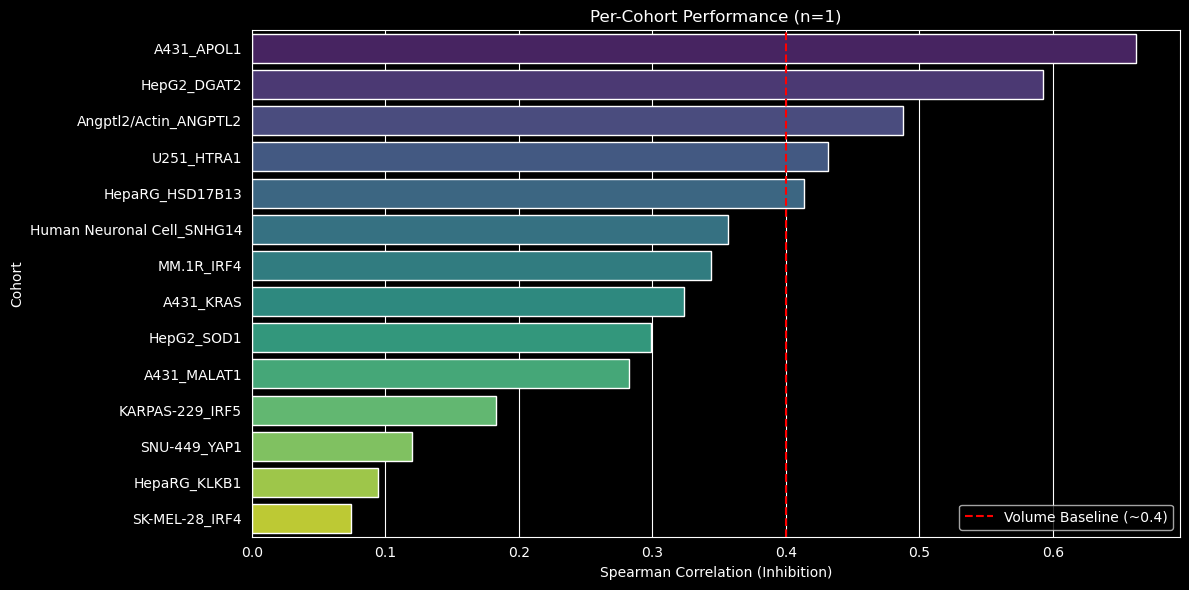

In [40]:
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import LeaveOneGroupOut
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

# ---------------------------------------------------------
# 1. SETUP & CONFIGURATION
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()

VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Use the robust features identified in your physics runs
# Adding MFE and GC content back in as you noted they are "super strong"
selected_features = [
    'Sequence_stop_codon_count',
    'LNA_DIFF_37_HYBR',
    'off_target_single_RPL7_c0',
    'mfe_win65_flank120_step15',  # Fold (mfe)
    'Sequence_gc_content',        # GC Content
    'PSDNA_RNA_MD_37_PB_TOTAL_HYBR' # Hybridization
]

# Filtering for Robustness
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)
counts = df['cohort'].value_counts()
df_robust = df[df['cohort'].isin(counts[counts >= 40].index)].copy()

# ---------------------------------------------------------
# 2. BASELINE ANALYSIS (EC50 = 1)
# ---------------------------------------------------------
print("--- BASELINE ANALYSIS (EC50 = 1) ---")
for n in [1, 2, 3]:
    # If EC50 is 1, Inhibition is just a function of Volume
    baseline_preds = (df_robust[VOLUME_COL]**n / (df_robust[VOLUME_COL]**n + 1**n)) * 100
    corr, _ = spearmanr(df_robust[TARGET_COL], baseline_preds)
    print(f"n={n} | Global Baseline Spearman (Volume Effect Only): {corr:.4f}")

# ---------------------------------------------------------
# 3. GRID SEARCH FOR n (HILL COEFFICIENT)
# ---------------------------------------------------------
results_per_n = {}

print("\n--- GRID SEARCH FOR n (LOCO VALIDATION) ---")
for n in [1, 2, 3]:
    # Transform Target
    inh_clipped = df_robust[TARGET_COL].clip(1, 99) / 100.0
    df_robust['log_ec50'] = np.log10(df_robust[VOLUME_COL] * ((1.0 / inh_clipped) - 1.0)**(1.0/n))

    logo = LeaveOneGroupOut()
    cohort_stats = []

    params = {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05,
              'device': 'cuda', 'tree_method': 'hist', 'verbosity': 0}

    for train_idx, val_idx in logo.split(df_robust[selected_features], df_robust['log_ec50'], groups=df_robust['cohort']):
        X_tr, y_tr = df_robust.iloc[train_idx][selected_features], df_robust.iloc[train_idx]['log_ec50']
        X_val, y_val = df_robust.iloc[val_idx][selected_features], df_robust.iloc[val_idx]['log_ec50']

        # Train & Predict Potency
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        pred_log_ec50 = model.predict(X_val)

        # Reconstruct Inhibition
        val_vols = df_robust.iloc[val_idx][VOLUME_COL]
        pred_inh = (val_vols**n / (val_vols**n + (10**pred_log_ec50)**n)) * 100

        # Score
        cohort_name = df_robust.iloc[val_idx]['cohort'].iloc[0]
        actual_inh = df_robust.iloc[val_idx][TARGET_COL]
        corr, _ = spearmanr(actual_inh, pred_inh)
        print (f"cohort {cohort_name}, spearman {corr}")
        cohort_stats.append({'cohort': cohort_name, 'spearman': corr})

    res_df = pd.DataFrame(cohort_stats)
    avg_score = res_df['spearman'].mean()
    results_per_n[n] = res_df
    print(f"n={n} | Average Cross-Cohort Spearman: {avg_score:.4f}")

# ---------------------------------------------------------
# 4. PLOTTING RESULTS (FOR BEST n)
# ---------------------------------------------------------
best_n = max(results_per_n, key=lambda k: results_per_n[k]['spearman'].mean())
plot_df = results_per_n[best_n].sort_values('spearman', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='spearman', y='cohort', palette='viridis')
plt.axvline(0.4, color='red', linestyle='--', label='Volume Baseline (~0.4)')
plt.title(f"Per-Cohort Performance (n={best_n})")
plt.xlabel("Spearman Correlation (Inhibition)")
plt.ylabel("Cohort")
plt.legend()
plt.tight_layout()
plt.savefig('cohort_performance.png')
print(f"\nSaved performance plot to cohort_performance.png using best n={best_n}")

In [41]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import warnings

# ---------------------------------------------------------
# 1. PREP DATA & DERIVE EC50
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()
VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Clip and Derive Log_EC50 (Targeting n=1 for the baseline)
# Formula: EC50 = Vol * (1/Inh - 1)
inh_clipped = df[TARGET_COL].clip(1, 99) / 100.0
df['log_ec50'] = np.log10(df[VOLUME_COL] * ( (1.0 / inh_clipped) - 1.0 ))

# Create Cohorts and Filter for Robustness
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)
counts = df['cohort'].value_counts()
df_robust = df[df['cohort'].isin(counts[counts >= 40].index)].copy()

# ---------------------------------------------------------
# 2. DEFINE FEATURES
# ---------------------------------------------------------
# Exclude metadata and non-features
ignore = [TARGET_COL, VOLUME_COL, 'log_ec50', 'cohort', CELL_LINE, CANONICAL_GENE,
          'index_v2', 'Unnamed: 0', 'ISIS', 'replicate_count', 'total_replicate_count']

# Focus on Intrinsic Features (Exclude OT_ as discussed, or keep for full discovery)
candidate_features = [c for c in df_robust.select_dtypes(include=[np.number]).columns
                      if c not in ignore and not c.startswith('OT_')]

print(f"Running discovery on {len(candidate_features)} features across {df_robust['cohort'].nunique()} cohorts...")

# ---------------------------------------------------------
# 3. CALCULATE METRICS
# ---------------------------------------------------------
discovery_results = []
X = df_robust[candidate_features].fillna(0) # Simple fill for MI
y = df_robust['log_ec50']

# Mutual Information (Captures complex non-linear physics)
print("Calculating Mutual Information (this may take a minute)...")
mi_scores = mutual_info_regression(X, y)
mi_dict = dict(zip(candidate_features, mi_scores))

for feat in candidate_features:
    # A. Global Spearman
    glob_s, _ = spearmanr(df_robust[feat], y)

    # B. Consistency (Average Intra-Cohort Spearman)
    intra_corrs = []
    for name, group in df_robust.groupby('cohort'):
        if len(group) > 5:
            s, _ = spearmanr(group[feat], group['log_ec50'])
            if not np.isnan(s):
                intra_corrs.append(s)
    consistency = np.mean(intra_corrs) if intra_corrs else 0

    discovery_results.append({
        'Feature': feat,
        'Global_Spearman': glob_s,
        'Mutual_Info': mi_dict[feat],
        'Intra_Consistency': consistency,
        'Abs_Global': abs(glob_s)
    })

# ---------------------------------------------------------
# 4. RANKING TABLE
# ---------------------------------------------------------
results_table = pd.DataFrame(discovery_results).sort_values('Intra_Consistency', ascending=False)
print("\nTOP 15 BIOLOGICAL FEATURES (Ranked by Intra-Cohort Consistency):")
print(results_table[['Feature', 'Intra_Consistency', 'Global_Spearman', 'Mutual_Info']].head(15))

# ---------------------------------------------------------
# 5. PER-COHORT ANALYSIS OF TOP 5
# ---------------------------------------------------------
top_5 = results_table['Feature'].head(5).tolist()
cohort_matrix = []

for name, group in df_robust.groupby('cohort'):
    row = {'cohort': name}
    for feat in top_5:
        s, _ = spearmanr(group[feat], group['log_ec50'])
        row[feat] = s
    cohort_matrix.append(row)

cohort_comparison = pd.DataFrame(cohort_matrix).set_index('cohort')
print("\nPER-COHORT SPEARMAN (For Top 5 Features):")
print(cohort_comparison)

Running discovery on 211 features across 14 cohorts...
Calculating Mutual Information (this may take a minute)...

TOP 15 BIOLOGICAL FEATURES (Ranked by Intra-Cohort Consistency):
                                          Feature  Intra_Consistency  \
16                               LNA_DIFF_37_HYBR           0.219715   
28                           Modification_in_core           0.180386   
62                               Sequence_at_skew           0.170875   
41                  PSDNA_RNA_MD_37_GB_TOTAL_HYBR           0.159549   
42                  PSDNA_RNA_MD_37_PB_TOTAL_HYBR           0.157331   
19                         MOE_DIFF_37_MD_PB_HYBR           0.149758   
56   RNaseH1_score_dinucleotide_R4a_dinuc_dynamic           0.139519   
18                         MOE_DIFF_37_MD_GB_HYBR           0.135414   
194                                sense_length_x           0.134525   
210                                sense_length_y           0.134525   
53                      RNas

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from tauso.data.consts import CELL_LINE, CANONICAL_GENE, INHIBITION
import warnings

# ---------------------------------------------------------
# 1. DERIVE POTENCY (EC50)
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
df = merged_df.copy()
VOLUME_COL = 'ASO_volume(nM)'
TARGET_COL = INHIBITION

# Using n=1 for the discovery baseline
inh_clipped = df[TARGET_COL].clip(1, 99) / 100.0
df['log_ec50'] = np.log10(df[VOLUME_COL] * ( (1.0 / inh_clipped) - 1.0 ))

df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)
df_robust = df[df['cohort'].map(df['cohort'].value_counts()) >= 40].copy()

# ---------------------------------------------------------
# 2. CALCULATE ALL-VS-ALL INTRA-COHORT CORRELATIONS
# ---------------------------------------------------------
ignore = [TARGET_COL, VOLUME_COL, 'log_ec50', 'cohort', CELL_LINE, CANONICAL_GENE, 'log_inhibition', 'index_v2'] + features_to_ignore
candidate_features = [c for c in df_robust.select_dtypes(include=[np.number]).columns
                      if c not in ignore and not c.startswith('OT_')]

all_corrs = []

for name, group in df_robust.groupby('cohort'):
    y = group['log_ec50']
    for feat in candidate_features:
        # We only care if the feature actually varies in this cohort
        if group[feat].std() > 1e-6:
            c, _ = spearmanr(group[feat], y)
            if not np.isnan(c):
                all_corrs.append({'cohort': name, 'feature': feat, 'spearman': c})

corr_df = pd.DataFrame(all_corrs)

# ---------------------------------------------------------
# 3. ANALYSIS: TOP FEATURES PER COHORT
# ---------------------------------------------------------
# Get the absolute best feature for every single cohort
best_per_cohort = corr_df.iloc[corr_df.groupby('cohort')['spearman'].idxmin()] # min because log_ec50 (lower is better)

print("--- TOP PREDICTOR FOR EACH COHORT ---")
print(best_per_cohort[['cohort', 'feature', 'spearman']].sort_values('spearman'))

# ---------------------------------------------------------
# 4. CHEMISTRY HEAD-TO-HEAD: LNA vs cEt
# ---------------------------------------------------------
print("\n--- CHEMISTRY HEAD-TO-HEAD ---")

chem_comparison = corr_df[corr_df['feature'].isin(['LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR'])]
pivot_chem = chem_comparison.pivot(index='cohort', columns='feature', values='spearman')

# Identify which cohorts are LNA-driven vs cEt-driven
def identify_chem(row):
    if pd.isna(row['LNA_DIFF_37_HYBR']) and not pd.isna(row['CET_DIFF_37_HYBR']): return 'cEt'
    if pd.isna(row['CET_DIFF_37_HYBR']) and not pd.isna(row['LNA_DIFF_37_HYBR']): return 'LNA'
    return 'Mixed/Other'

pivot_chem['Chemistry_Type'] = pivot_chem.apply(identify_chem, axis=1)
print(pivot_chem)

# ---------------------------------------------------------
# 5. THE "UNIFIED HYBRIDIZATION" SCORE
# ---------------------------------------------------------
# Since they are mutually exclusive, let's see if a combined feature is better
df_robust['Unified_Hybr_Diff'] = df_robust['LNA_DIFF_37_HYBR'].fillna(0) + df_robust['CET_DIFF_37_HYBR'].fillna(0)
unified_corrs = []
for name, group in df_robust.groupby('cohort'):
    c, _ = spearmanr(group['Unified_Hybr_Diff'], group['log_ec50'])
    unified_corrs.append(c)

print(f"\nMean Intra-Cohort Spearman for Unified Hybridization: {np.mean(unified_corrs):.4f}")

--- TOP PREDICTOR FOR EACH COHORT ---
                          cohort                                 feature  \
855                  HepG2_DGAT2                 Treatment_Period(hours)   
2194                  U251_HTRA1                Modification_block_count   
338                    A431_KRAS                 Treatment_Period(hours)   
1761                  MM.1R_IRF4                mfe_win35_flank120_step4   
1359  Human Neuronal Cell_SNHG14                 Modification_5prime_run   
2031                SNU-449_YAP1                           DNA_HYBR_DIFF   
576        Angptl2/Actin_ANGPTL2               mfe_win35_flank120_step10   
1576             KARPAS-229_IRF5                  Sequence_internal_fold   
2027              SK-MEL-28_IRF4                           sense_start_x   
1225                HepaRG_KLKB1                        Sequence_entropy   
413                  A431_MALAT1               mfe_win55_flank120_step10   
891                   HepG2_SOD1          Sequence

Training on 13 robust cohorts. Testing on HepaRG_HSD17B13 (N=3985)
FORCED PHYSICS MODEL: HepaRG_HSD17B13
--------------------------------------------------
Biological Spearman (EC50 Space): 0.1473
Clinical Spearman   (Inh % Space): 0.4809


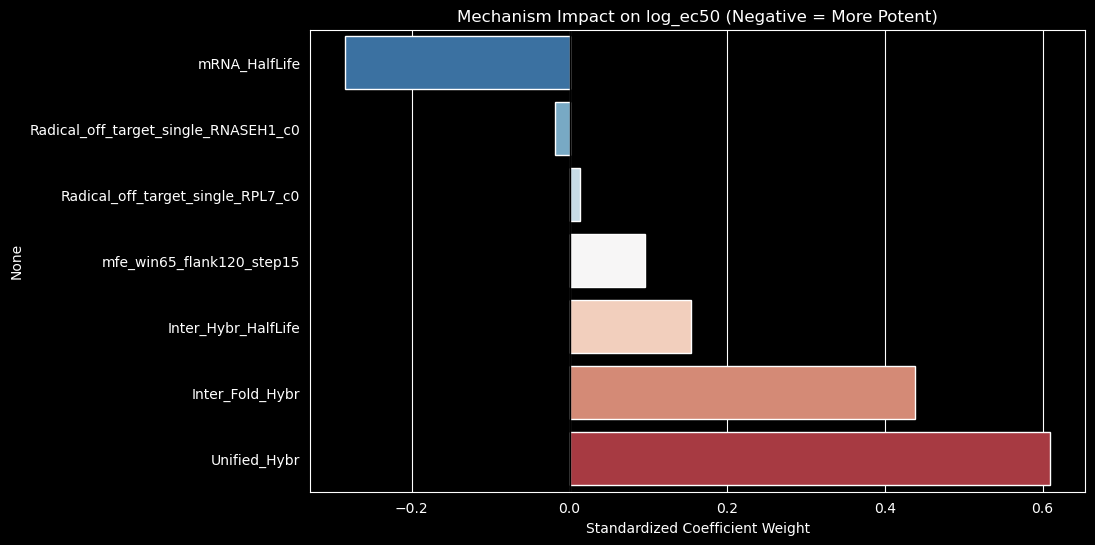

In [54]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. DATA PREP & LOG_EC50 DERIVATION
# ---------------------------------------------------------
df = merged_df.copy()

# Using your session constants
VOLUME_COL = 'ASO_volume(nM)'
CELL_LINE_COL = 'Cell_line'
GENE_COL = CANONICAL_GENE

# Derive Potency (EC50) to strip volume bias
# Formula: EC50 = Vol * ( (1/Inh) - 1 )
inh_clipped = df[INHIBITION].clip(1, 99) / 100.0
df['log_ec50'] = np.log10(df[VOLUME_COL] * ((1.0 / inh_clipped) - 1.0))

# Standardize cohort ID
df['cohort'] = df[CELL_LINE_COL].astype(str) + '_' + df[GENE_COL].astype(str)

test_cohort_id = 'HepaRG_HSD17B13'
if test_cohort_id not in df['cohort'].unique():
    print(f"CRITICAL: {test_cohort_id} not found. Check if CELL_LINE or CANONICAL_GENE values changed.")
else:
    # Split BEFORE robust filtering to preserve test set
    df_test = df[df['cohort'] == test_cohort_id].copy()
    df_others = df[df['cohort'] != test_cohort_id].copy()

    # Apply N>=40 filter only to training data
    counts = df_others['cohort'].value_counts()
    df_dev = df_others[df_others['cohort'].isin(counts[counts >= 40].index)].copy()

    print(f"Training on {df_dev['cohort'].nunique()} robust cohorts. Testing on {test_cohort_id} (N={len(df_test)})")

    # ---------------------------------------------------------
    # 2. MECHANISTIC FEATURE ENGINEERING
    # ---------------------------------------------------------
    def engineer_physics(data, train_ref):
        # a. Unified Hybridization (Mutually exclusive LNA/cEt)
        data['Unified_Hybr'] = data['LNA_DIFF_37_HYBR'].fillna(0) + data['CET_DIFF_37_HYBR'].fillna(0)

        # b. Interaction Features (The "Biology Logic")
        # Target Accessibility * Binding Affinity
        data['Inter_Fold_Hybr'] = data['mfe_win65_flank120_step15'] * data['Unified_Hybr']
        # Affinity * mRNA Turnover
        data['Inter_Hybr_HalfLife'] = data['Unified_Hybr'] * data['mRNA_HalfLife']

        # c. Radicalized Off-Targets (Sponge Switch)
        # ReLU-style high-pass filter at the 98th percentile
        for ot in ['off_target_single_RPL7_c0', 'off_target_single_RNASEH1_c0']:
            thresh = train_ref[ot].quantile(0.98)
            data[f'Radical_{ot}'] = np.where(data[ot] > thresh, data[ot], 0.0)
        return data

    df_dev = engineer_physics(df_dev, df_dev)
    df_test = engineer_physics(df_test, df_dev)

    physics_features = [
        'Unified_Hybr',
        'mfe_win65_flank120_step15',
        'mRNA_HalfLife',
        'Inter_Fold_Hybr',
        'Inter_Hybr_HalfLife',
        'Radical_off_target_single_RPL7_c0',
        'Radical_off_target_single_RNASEH1_c0'
    ]

    # ---------------------------------------------------------
    # 3. TRAINING & EVALUATION
    # ---------------------------------------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_dev[physics_features].fillna(0))
    X_test = scaler.transform(df_test[physics_features].fillna(0))

    y_train = df_dev['log_ec50']
    y_test = df_test['log_ec50']

    # Ridge Regression for stable coefficients
    model = Ridge(alpha=10.0)
    model.fit(X_train, y_train)

    # Predict log_ec50 (Pure Potency)
    pred_log_ec50 = model.predict(X_test)
    bio_score, _ = spearmanr(y_test, pred_log_ec50)

    # Reconstruct Inhibition % (The Clinical Metric)
    pred_ec50 = 10**pred_log_ec50
    clin_preds = (df_test[VOLUME_COL] / (df_test[VOLUME_COL] + pred_ec50)) * 100
    clin_score, _ = spearmanr(df_test[INHIBITION], clin_preds)

    print("="*50)
    print(f"FORCED PHYSICS MODEL: {test_cohort_id}")
    print("-" * 50)
    print(f"Biological Spearman (EC50 Space): {bio_score:.4f}")
    print(f"Clinical Spearman   (Inh % Space): {clin_score:.4f}")
    print("="*50)

    # 4. COEFFICIENT INTERPRETATION
    # ---------------------------------------------------------
    weights = pd.Series(model.coef_, index=physics_features).sort_values()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=weights.values, y=weights.index, palette='RdBu_r')
    plt.axvline(0, color='black', lw=1)
    plt.title("Mechanism Impact on log_ec50 (Negative = More Potent)")
    plt.xlabel("Standardized Coefficient Weight")
    plt.show()

Starting LOCO CV across 14 cohorts...


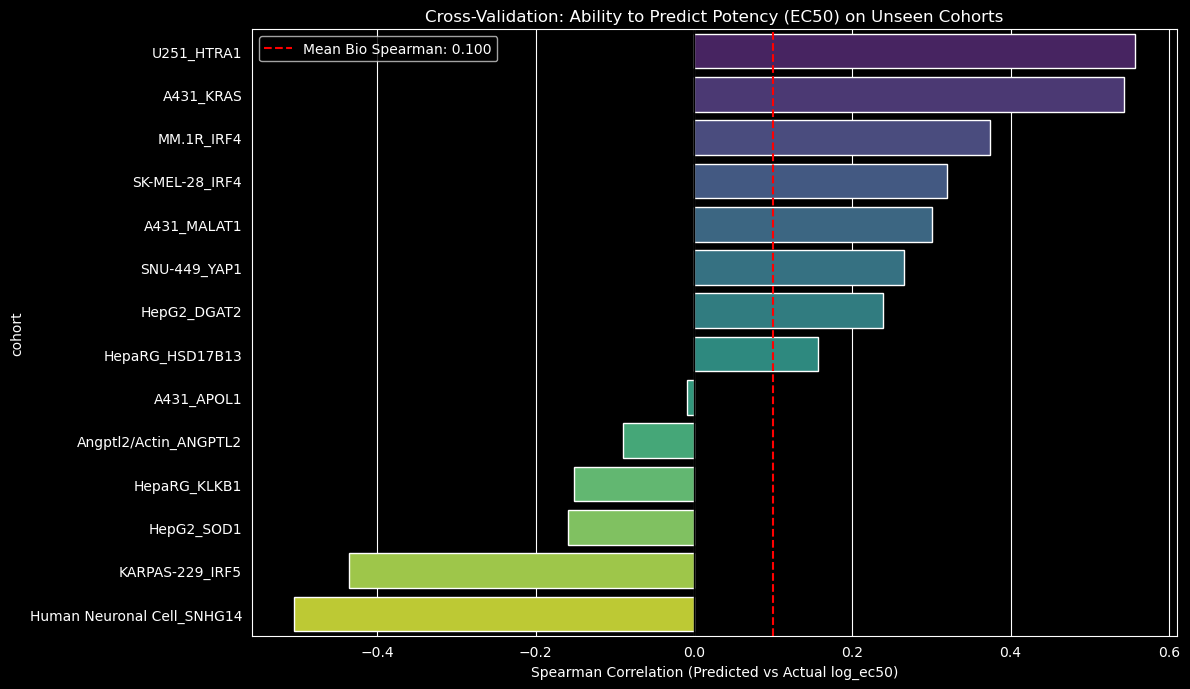


Summary Statistics:
       bio_spearman  clin_spearman
count     14.000000      14.000000
mean       0.100283       0.289216
std        0.333858       0.282582
min       -0.505325      -0.291203
25%       -0.135518       0.120135
50%        0.197705       0.329295
75%        0.314798       0.476711
max        0.556713       0.699027


In [72]:
from tauso.data.consts import TREATMENT_PERIOD
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. SETUP & TARGET DERIVATION
# ---------------------------------------------------------
df = merged_df.copy()

# Using your constants
VOLUME_COL = 'ASO_volume(nM)'
CELL_LINE_COL = 'Cell_line'
GENE_COL = CANONICAL_GENE

# Pure Potency Target (EC50)
inh_clipped = df[INHIBITION].clip(1, 99) / 100.0
df['log_ec50'] = np.log10(df[VOLUME_COL] * ((1.0 / inh_clipped) - 1.0))

# Cohort Definition
df['cohort'] = df[CELL_LINE_COL].astype(str) + '_' + df[GENE_COL].astype(str)

# Filter for robust cohorts (N >= 40)
counts = df['cohort'].value_counts()
df_robust = df[df['cohort'].isin(counts[counts >= 40].index)].copy()

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING (Inside CV Loop)
# ---------------------------------------------------------

def get_physics_features(data, train_ref, cfg):
    """
    Physics feature builder with configurable interactions.
    cfg toggles interactions/transformations without touching outer loop.
    """
    # 0. Define Length (Using the sense_length feature we saw earlier)
    aso_len = data['sense_length_x'].clip(lower=1)

    # 1. Length-Normalized Hybridization (Affinity Density)
    data['MOE_Hybr_Density'] = data['MOE_DIFF_37_MD_PB_HYBR'].fillna(0) / aso_len
    data['cEt_Hybr_Density'] = data['CET_DIFF_37_HYBR'].fillna(0) / aso_len

    if cfg.get('abs_hybr'):
        data['MOE_Hybr_Abs'] = data['MOE_Hybr_Density'].abs()
        data['cEt_Hybr_Abs'] = data['cEt_Hybr_Density'].abs()

    if cfg.get('hybr_sq'):
        data['MOE_Hybr_Density_Sq'] = data['MOE_Hybr_Density'] ** 2
        data['cEt_Hybr_Density_Sq'] = data['cEt_Hybr_Density'] ** 2

    if cfg.get('hybr_cu'):
        data['MOE_Hybr_Density_Cu'] = data['MOE_Hybr_Density'] ** 3
        data['cEt_Hybr_Density_Cu'] = data['cEt_Hybr_Density'] ** 3

    # 2. Accessibility
    acc_col = 'mfe_win45_flank120_step7'

    if cfg.get('acc_log1p'):
        data['Acc_Log1p'] = np.log1p(np.clip(data[acc_col], a_min=0, a_max=None))

    # 3. Docking / Synergy
    data['Docking_MOE'] = data[acc_col] * data['MOE_Hybr_Density']
    data['Docking_cEt'] = data[acc_col] * data['cEt_Hybr_Density']

    if cfg.get('dock_abs'):
        data['Docking_MOE_Abs'] = data[acc_col] * data['MOE_Hybr_Density'].abs()
        data['Docking_cEt_Abs'] = data[acc_col] * data['cEt_Hybr_Density'].abs()

    if cfg.get('dock_sq'):
        data['Docking_MOE_Sq'] = data['Docking_MOE'] ** 2
        data['Docking_cEt_Sq'] = data['Docking_cEt'] ** 2

    # 4. Temporal & Biological Context
    data['Time_Clipped'] = np.minimum(data[TREATMENT_PERIOD], 48)
    data['ASO_Length'] = aso_len

    if cfg.get('time_sq'):
        data['Time_Clipped_Sq'] = data['Time_Clipped'] ** 2

    if cfg.get('len_sq'):
        data['ASO_Length_Sq'] = aso_len ** 2

    # 5. Radicalized Off-Targets
    for ot in ['off_target_score_specific_MECH_n100_c1000', 'off_target_single_RPL7_c0']:
        if ot in data.columns:
            thresh = train_ref[ot].quantile(0.98)
            data[f'Radical_{ot}'] = np.where(data[ot] > thresh, data[ot], 0.0)
        else:
            data[f'Radical_{ot}'] = 0.0

    # 6. Optional interactions
    if cfg.get('time_x_moe'):
        data['Time_x_MOE'] = data['Time_Clipped'] * data['MOE_Hybr_Density']

    if cfg.get('time_x_acc'):
        data['Time_x_Acc'] = data['Time_Clipped'] * data[acc_col]

    # Feature list
    features = [
        'MOE_Hybr_Density',
        'cEt_Hybr_Density',
        'Docking_MOE',
        'Docking_cEt',
        acc_col,
        'ASO_Length',
        'Time_Clipped',
        'mRNA_HalfLife'
    ]

    if cfg.get('abs_hybr'):
        features += ['MOE_Hybr_Abs', 'cEt_Hybr_Abs']
    if cfg.get('hybr_sq'):
        features += ['MOE_Hybr_Density_Sq', 'cEt_Hybr_Density_Sq']
    if cfg.get('hybr_cu'):
        features += ['MOE_Hybr_Density_Cu', 'cEt_Hybr_Density_Cu']
    if cfg.get('acc_log1p'):
        features += ['Acc_Log1p']
    if cfg.get('dock_abs'):
        features += ['Docking_MOE_Abs', 'Docking_cEt_Abs']
    if cfg.get('dock_sq'):
        features += ['Docking_MOE_Sq', 'Docking_cEt_Sq']
    if cfg.get('time_sq'):
        features += ['Time_Clipped_Sq']
    if cfg.get('len_sq'):
        features += ['ASO_Length_Sq']
    if cfg.get('time_x_moe'):
        features += ['Time_x_MOE']
    if cfg.get('time_x_acc'):
        features += ['Time_x_Acc']

    if cfg.get('radical_ot'):
        features += ['Radical_off_target_single_RPL7_c0']

    return data[features]

# ---------------------------------------------------------
# 3. LOCO CROSS-VALIDATION LOOP (Config Sweep)
# ---------------------------------------------------------
logo = LeaveOneGroupOut()

configs = [
    dict(name='base', abs_hybr=False, hybr_sq=False, hybr_cu=False, acc_log1p=False, dock_abs=False, dock_sq=False, time_sq=False, len_sq=False, time_x_moe=False, time_x_acc=False, radical_ot=True),
    dict(name='sq_terms', abs_hybr=False, hybr_sq=True, hybr_cu=False, acc_log1p=False, dock_abs=False, dock_sq=True, time_sq=True, len_sq=True, time_x_moe=False, time_x_acc=False, radical_ot=True),
    dict(name='abs_synergy', abs_hybr=True, hybr_sq=False, hybr_cu=False, acc_log1p=True, dock_abs=True, dock_sq=False, time_sq=False, len_sq=False, time_x_moe=True, time_x_acc=True, radical_ot=True),
    dict(name='cubic_terms', abs_hybr=False, hybr_sq=True, hybr_cu=True, acc_log1p=False, dock_abs=False, dock_sq=True, time_sq=False, len_sq=False, time_x_moe=True, time_x_acc=False, radical_ot=True),
    dict(name='no_radical', abs_hybr=False, hybr_sq=True, hybr_cu=False, acc_log1p=False, dock_abs=False, dock_sq=True, time_sq=True, len_sq=True, time_x_moe=False, time_x_acc=False, radical_ot=False),
]

summary_rows = []

print(f"Starting LOCO CV across {df_robust['cohort'].nunique()} cohorts...")

for cfg in configs:
    cv_results = []

    for train_idx, val_idx in logo.split(df_robust, groups=df_robust['cohort']):
        df_train_raw = df_robust.iloc[train_idx].copy()
        df_val_raw = df_robust.iloc[val_idx].copy()
        cohort_name = df_val_raw['cohort'].iloc[0]

        X_train_raw = get_physics_features(df_train_raw, df_train_raw, cfg)
        X_val_raw = get_physics_features(df_val_raw, df_train_raw, cfg)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw.fillna(0))
        X_val = scaler.transform(X_val_raw.fillna(0))

        y_train = df_train_raw['log_ec50']
        y_val = df_val_raw['log_ec50']

        model = Ridge(alpha=10.0)
        model.fit(X_train, y_train)

        pred_log_ec50 = model.predict(X_val)
        bio_corr, _ = spearmanr(y_val, pred_log_ec50)

        pred_ec50 = 10**pred_log_ec50
        clin_preds = (df_val_raw[VOLUME_COL] / (df_val_raw[VOLUME_COL] + pred_ec50)) * 100
        clin_corr, _ = spearmanr(df_val_raw[INHIBITION], clin_preds)

        cv_results.append({
            'cohort': cohort_name,
            'bio_spearman': bio_corr,
            'clin_spearman': clin_corr,
            'N': len(df_val_raw)
        })

    results_df = pd.DataFrame(cv_results)
    min_bio = results_df['bio_spearman'].min()
    min_clin = results_df['clin_spearman'].min()
    mean_bio = results_df['bio_spearman'].mean()
    mean_clin = results_df['clin_spearman'].mean()

    summary_rows.append({
        'config': cfg['name'],
        'min_bio_spearman': min_bio,
        'min_clin_spearman': min_clin,
        'mean_bio_spearman': mean_bio,
        'mean_clin_spearman': mean_clin,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['min_bio_spearman', 'min_clin_spearman'], ascending=False)
print(summary_df)

# Show top config details
best_cfg_name = summary_df.iloc[0]['config']
print(f"\nBest config by min-bio/min-clin: {best_cfg_name}")

# ---------------------------------------------------------
# 4. VISUALIZATION OF GENERALIZATION (Best config only)
# ---------------------------------------------------------
best_cfg = next(c for c in configs if c['name'] == best_cfg_name)
cv_results = []

for train_idx, val_idx in logo.split(df_robust, groups=df_robust['cohort']):
    df_train_raw = df_robust.iloc[train_idx].copy()
    df_val_raw = df_robust.iloc[val_idx].copy()
    cohort_name = df_val_raw['cohort'].iloc[0]

    X_train_raw = get_physics_features(df_train_raw, df_train_raw, best_cfg)
    X_val_raw = get_physics_features(df_val_raw, df_train_raw, best_cfg)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw.fillna(0))
    X_val = scaler.transform(X_val_raw.fillna(0))

    y_train = df_train_raw['log_ec50']
    y_val = df_val_raw['log_ec50']

    model = Ridge(alpha=10.0)
    model.fit(X_train, y_train)

    pred_log_ec50 = model.predict(X_val)
    bio_corr, _ = spearmanr(y_val, pred_log_ec50)

    pred_ec50 = 10**pred_log_ec50
    clin_preds = (df_val_raw[VOLUME_COL] / (df_val_raw[VOLUME_COL] + pred_ec50)) * 100
    clin_corr, _ = spearmanr(df_val_raw[INHIBITION], clin_preds)

    cv_results.append({
        'cohort': cohort_name,
        'bio_spearman': bio_corr,
        'clin_spearman': clin_corr,
        'N': len(df_val_raw)
    })

results_df = pd.DataFrame(cv_results).sort_values('bio_spearman', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=results_df, x='bio_spearman', y='cohort', palette='viridis')
plt.axvline(0, color='black', lw=1)
plt.axvline(results_df['bio_spearman'].mean(), color='red', linestyle='--',
            label=f"Mean Bio Spearman: {results_df['bio_spearman'].mean():.3f}")

plt.title("Cross-Validation: Ability to Predict Potency (EC50) on Unseen Cohorts")
plt.xlabel("Spearman Correlation (Predicted vs Actual log_ec50)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(results_df[['bio_spearman', 'clin_spearman']].describe())



In [62]:
df['cohort'].unique()

array(['T_cells_IRF5', 'HepG2_SOD1', 'HepG2_DGAT2',
       'N/TERT-1_keratinocytes_SOD1', 'N/TERT-1_keratinocytes_MALAT1',
       'HepG2_KLKB1', 'N/TERT-1_keratinocytes_KRAS',
       'N/TERT-1_keratinocytes_IRF4', 'K562_IRF4', 'MRC5VA_KRAS',
       'HepG2_YAP1', 'N/TERT-1_keratinocytes_IRF5',
       'N/TERT-1_keratinocytes_APOL1', 'HepG2_HSD17B13',
       'neural_precursor_cells_ANGPTL2', 'iPSN_SNHG14',
       'neural_precursor_cells_HTRA1'], dtype=object)

Analyzing KARPAS-229_IRF5 with N=291 samples...

--- TOP 10 FEATURES DOMINATING DGAT2 ---
Treatment_Period(hours)                     0.088683
off_target_score_specific_ARTM_n100_c900    0.075584
sense_start_x                               0.057893
OT_Spec_Rank5_c600_Score                    0.045687
Sequence_hairpin_tm                         0.041527
mfe_win35_flank120_step15                   0.038950
TOTAL_DNA_HYBR                              0.038003
mfe_win45_flank120_step4                    0.036462
mfe_win35_flank120_step10                   0.021654
RNaseH1_Krel_score_R4a_krel_dynamic         0.020062
dtype: float32


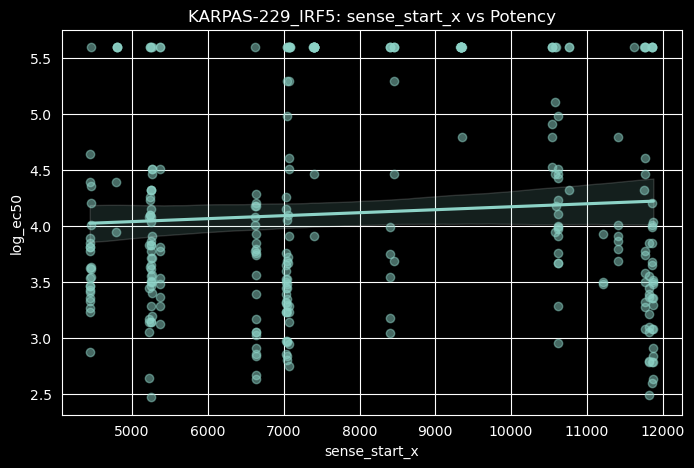

In [70]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

CELL_LINE = 'Cell_line'

# 1. ISOLATE THE PEAK COHORT
# ---------------------------------------------------------
df = merged_df.copy()
df['cohort'] = df[CELL_LINE].astype(str) + '_' + df[CANONICAL_GENE].astype(str)

target_cohort = 'KARPAS-229_IRF5'
df_dgat2 = df[df['cohort'] == target_cohort].copy()

# Derive log_ec50 (The Ground Truth for design)
inh_clipped = df_dgat2[INHIBITION].clip(1, 99) / 100.0
df_dgat2['log_ec50'] = np.log10(df_dgat2['ASO_volume(nM)'] * ((1.0 / inh_clipped) - 1.0))

print(f"Analyzing {target_cohort} with N={len(df_dgat2)} samples...")

# 2. RADICALIZE & CLEAN CANDIDATES
# ---------------------------------------------------------
ignore = [INHIBITION, 'ASO_volume(nM)', 'log_ec50', 'cohort', CELL_LINE, CANONICAL_GENE, 'index_v2', 'Unnamed: 0', 'log_inhibition', 'probe_count']
candidates = [c for c in df_dgat2.select_dtypes(include=[np.number]).columns if c not in ignore]

# Radicalize sparse features specifically for DGAT2
for col in [c for c in candidates if 'off_target' in c or 'RNaseH1' in c]:
    thresh = df_dgat2[col].quantile(0.95)
    if thresh > df_dgat2[col].min():
        df_dgat2[f'Radical_{col}'] = np.where(df_dgat2[col] > thresh, df_dgat2[col], 0.0)

final_candidates = [c for c in df_dgat2.columns if c in candidates or c.startswith('Radical_')]

# 3. TRAIN PEAK MODEL
# ---------------------------------------------------------
X = df_dgat2[final_candidates].fillna(0)
y = df_dgat2['log_ec50']

# Use a deep tree to catch the interactions that dominate this gene
model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, device='cuda', tree_method='hist')
model.fit(X, y)

# 4. DISCOVER THE DOMINANT FEATURES
# ---------------------------------------------------------
importances = pd.Series(model.feature_importances_, index=final_candidates).sort_values(ascending=False)

print("\n--- TOP 10 FEATURES DOMINATING DGAT2 ---")
print(importances.head(10))

# Plot the top feature vs log_ec50 to see the shape
top_feat = 'sense_start_x'
plt.figure(figsize=(8, 5))
sns.regplot(data=df_dgat2, x=top_feat, y='log_ec50', scatter_kws={'alpha':0.5})
plt.title(f"{target_cohort}: {top_feat} vs Potency")
plt.show()

Stress-testing KARPAS-229_IRF5 | N = 291

MAX POSSIBLE SPEARMAN (Overfit) on KARPAS: 0.9698

--- TOP 10 FEATURES FOR KARPAS ---
mfe_win45_flank120_step7                     0.194476
Treatment_Period(hours)                      0.102666
off_target_score_specific_MECH_n100_c1000    0.094165
sense_start_x                                0.083909
off_target_score_specific_MECH_n50_c900      0.033371
ENC_score_70_CDS                             0.032983
off_target_score_specific_ARTM_n100_c900     0.031947
TOTAL_DNA_HYBR                               0.030239
off_target_score_specific_MECH_n25_c900      0.028869
OT_Spec_Rank5_c600_Score                     0.023692
dtype: float32


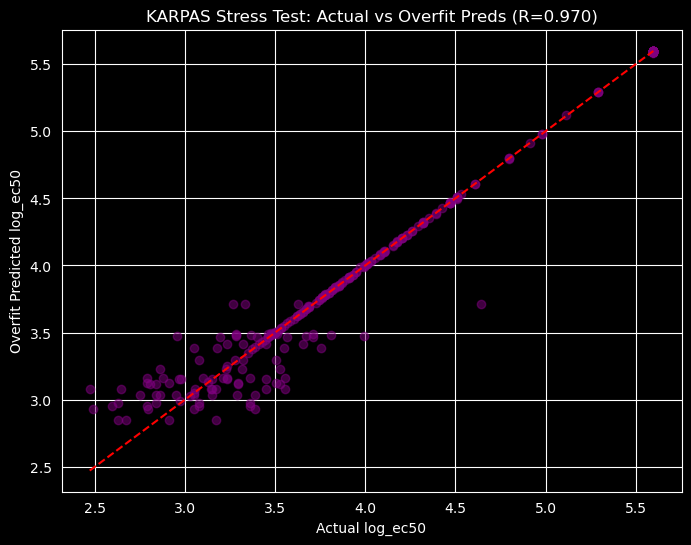

In [68]:
import xgboost as xgb
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ISOLATE KARPAS
# ---------------------------------------------------------
# Ensure CELL_LINE, CANONICAL_GENE, and INHIBITION are defined
df_karpas = merged_df[
    (merged_df[CELL_LINE] == 'KARPAS-229') &
    (merged_df[CANONICAL_GENE] == 'IRF5')
].copy()

# Derive log_ec50
inh_clipped = df_karpas[INHIBITION].clip(1, 99) / 100.0
df_karpas['log_ec50'] = np.log10(df_karpas['ASO_volume(nM)'] * ((1.0 / inh_clipped) - 1.0))

print(f"Stress-testing KARPAS-229_IRF5 | N = {len(df_karpas)}")

# 2. FEATURE SELECTION (Biological only, no metadata)
# ---------------------------------------------------------
ignore = [INHIBITION, 'ASO_volume(nM)', 'log_ec50', CELL_LINE, CANONICAL_GENE,
          'index_v2', 'Unnamed: 0', 'ISIS', 'replicate_count', 'total_replicate_count', 'log_inhibition']

# Focus on Intrinsic Design Features
candidates = [c for c in df_karpas.select_dtypes(include=[np.number]).columns if c not in ignore]

# Add Radical Switches (95th percentile)
for col in [c for c in candidates if 'off_target' in c or 'RNaseH1' in c]:
    thresh = df_karpas[col].quantile(0.95)
    if thresh > df_karpas[col].min():
        df_karpas[f'Radical_{col}'] = np.where(df_karpas[col] > thresh, df_karpas[col], 0.0)

final_features = [c for c in df_karpas.columns if c in candidates or c.startswith('Radical_')]

# 3. OVERFIT MODEL (High capacity)
# ---------------------------------------------------------
X = df_karpas[final_features].fillna(0)
y = df_karpas['log_ec50']

# Max_depth=10 is deep enough to catch almost any multi-feature physics interaction
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.05,
    subsample=1.0, # Use all data to see max potential
    colsample_bytree=1.0
)
model.fit(X, y)

# 4. RESULTS
# ---------------------------------------------------------
preds = model.predict(X)
score, _ = spearmanr(y, preds)

print(f"\nMAX POSSIBLE SPEARMAN (Overfit) on KARPAS: {score:.4f}")

# Look at what it used to get there
importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False)
print("\n--- TOP 10 FEATURES FOR KARPAS ---")
print(importances.head(10))

# Visualizing the Fit
plt.figure(figsize=(8, 6))
plt.scatter(y, preds, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f"KARPAS Stress Test: Actual vs Overfit Preds (R={score:.3f})")
plt.xlabel("Actual log_ec50")
plt.ylabel("Overfit Predicted log_ec50")
plt.show()